# Visualización de datos para la clasificación

# Explorando MNIST(modified National Institute of Standars and Technology dataset) y redes neuronales

El propósito de este documento es entender sobre redes neuronales y como varía su desempeño al utilizar diferentes optimizadores.

Antes de poder construir redes neuronales, necesitamos importar algunas cosas de Keras (datos de Internet) y preparar nuestros datos. El siguiente código extrae el conjunto de datos correspondientes a MNIST, proporcionado por Keras. Además, modifica las etiquetas de un valor numérico 0-9 a un vector one-hot encoded.

One-hot encoding hace referencia a un grupo de bits entre los cuales las combinaciones validas de valores son solo aquellas con un solo bit alto (1) y todas las demás bajas (0). Mirar la gráfica siguiente:
<center><img src="https://i.imgur.com/wKtY1Og.png" alt="drawing" width="400"/>

# Importación de Datos

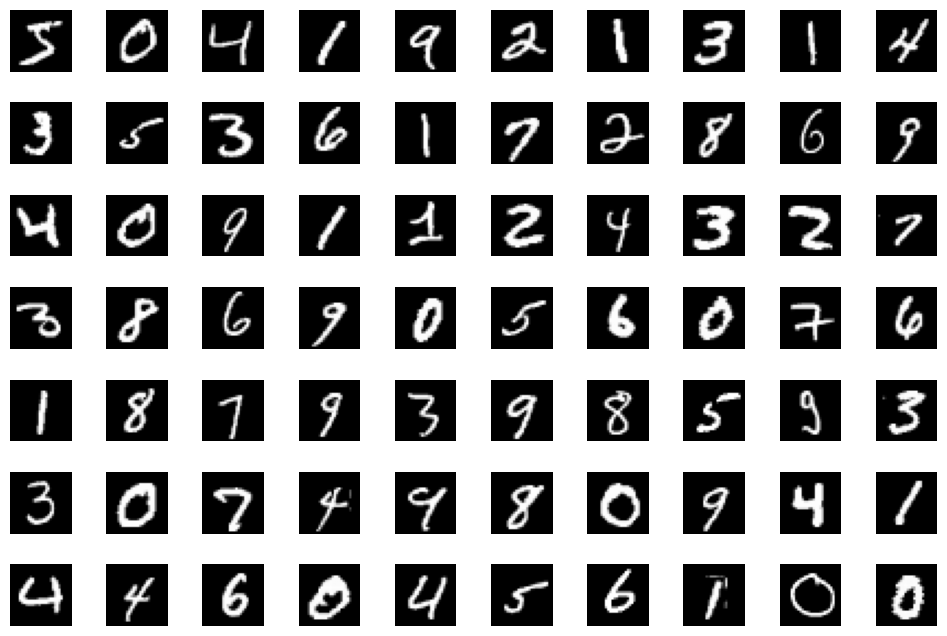

In [1]:
# @title
import matplotlib.pyplot as plt
import tensorflow as tf

# Load only the images (X_show) from the MNIST dataset
(X_show, _), _ = tf.keras.datasets.mnist.load_data()

# Plot a 10x7 grid of digit images
fig, axes = plt.subplots(7, 10, figsize=(12, 8))
fig.subplots_adjust(hspace=0.5, wspace=0.5)

for i, ax in enumerate(axes.flat):
    ax.imshow(X_show[i], cmap='gray')  # Display image in grayscale
    ax.axis('off')  # Hide axis
    # Removed the label display since y_train is not used
    # If you'd like to show indices instead, you can uncomment the next line:
    # ax.set_title(f'#{i}', fontsize=12)

plt.show()

# Instalación de TensorFlow

In [2]:
# @title
%pip install tensorflow


/Users/paulehmig/Documents/Personal/USFQ/MaestriaDataScience/Materias/MSDS_6005_Matematicas_y_Programacion_IA/Lab03/.venv/bin/python: No module named pip


Note: you may need to restart the kernel to use updated packages.


# Comparación de Optimizadores. Gráficas de  Loss/Accuracy vs. Epochs (ACTIVIDAD BASE)

Training with Gradient Descent (GD)...


/Users/paulehmig/Documents/Personal/USFQ/MaestriaDataScience/Materias/MSDS_6005_Matematicas_y_Programacion_IA/Lab03/.venv/lib/python3.13/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Training with Stochastic GD (SGD)...


Training with Mini-Batch SGD...


Training with Momentum SGD...


Training with Adam...


Training with RMSprop...


Training with RMSprop + Momentum...


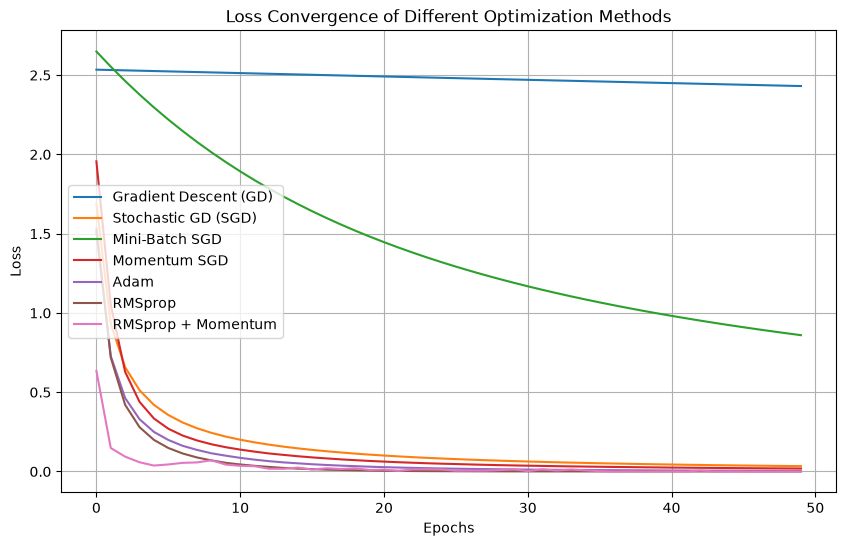

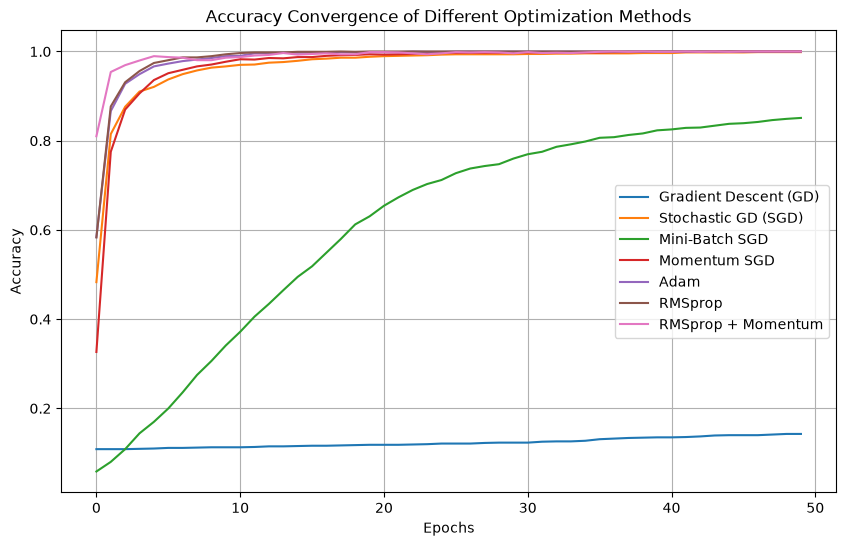

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
import tensorflow as tf

  # ---- Load and Preprocess Data ----
digits = load_digits()   # formato original-> (1797, 8, 8)
X = digits.images.reshape(len(digits.images), -1)  # Flatten images to 64 features, i.e., (1797, 64) ->  1797 samples con 64 features
y = digits.target.reshape(-1, 1)  # Labels, Convierte el vector de etiquetas de (1797,) a una matriz columna (1797, 1).

# Normalize features
scaler = StandardScaler()
X = scaler.fit_transform(X)  # se usa zscore para normalizar los datos de entrada

# One-hot encode labels
encoder = OneHotEncoder(sparse_output=False)  #False, formato de matriz densa tal como muestra la figura al comienzo del script

y = encoder.fit_transform(y)  # generamos las clases e.g.,   Clase 3 [0,0,0,1]

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# ---- Define Neural Network Model ----
def build_model(activation="tanh"):
    model = tf.keras.Sequential([
        tf.keras.layers.Dense(64, activation=activation, input_shape=(64,)),  # Input Layer  (64 porque esas son el numero de features)
        tf.keras.layers.Dense(32, activation=activation),  # Hidden Layer
        tf.keras.layers.Dense(10, activation="softmax")  # Output Layer (una por cada clase de dígito: 0-9, total 10 clases).
    ])
    return model

# ---- Set Learning Rate and Hyperparameters ----
learning_rate = 0.001  #
momentum_beta = 0.98  #
adam_beta1 = 0.9  #
adam_beta2 = 0.999  #
RMSprop_beta2=0.9

# ---- Define Optimizers with Modifiable beta1 and beta2 ----   AQUI VER COMO SE USA CADA DIFERENTE OPTIMIZADOR PARA LAS ACTIVIDADES POSTERIORES
optimizers = {
      "Gradient Descent (GD)": tf.keras.optimizers.SGD(learning_rate=learning_rate),
    "Stochastic GD (SGD)": tf.keras.optimizers.SGD(learning_rate=learning_rate, momentum=0.0),
    "Mini-Batch SGD": tf.keras.optimizers.SGD(learning_rate=learning_rate, momentum=0.0),
    "Momentum SGD": tf.keras.optimizers.SGD(learning_rate=learning_rate, momentum=momentum_beta),
    "Adam": tf.keras.optimizers.Adam(learning_rate=learning_rate, beta_1=adam_beta1, beta_2=adam_beta2),
    "RMSprop": tf.keras.optimizers.RMSprop(learning_rate=learning_rate, rho=0.9),
          "RMSprop + Momentum": tf.keras.optimizers.RMSprop(learning_rate=learning_rate, rho=RMSprop_beta2, momentum=momentum_beta)

}

# Definir los batch sizes para cada optimizador
batch_sizes = {
    "Gradient Descent (GD)": X_train.shape[0],  # Usa TODAS las muestras por iteración (GD)
    "Stochastic GD (SGD)": 1,  # Usa 1 muestra por iteración
    "Mini-Batch SGD": 32,  # Usa Mini-Batches de 32 muestras
    "Momentum SGD": 32,  # Igual que Mini-Batch, pero con memoria del gradiente
    "Adam": 32,  # Adam generalmente usa Mini-Batch
    "RMSprop": 32,  # RMSprop generalmente usa Mini-Batch
    "RMSprop + Momentum": 32,  # RMSprop generalmente usa Mini-Batch
}

# ---- Train Model with Each Optimizer ----
history_loss = {}
history_acc = {}

for name, optimizer in optimizers.items():
    print(f"Training with {name}...")
    model = build_model(activation="tanh")  # MODIFY ACTIVATION FUNCTION!
    model.compile(optimizer=optimizer, loss="categorical_crossentropy", metrics=["accuracy"])
    history = model.fit(X_train, y_train, epochs=50, batch_size=batch_sizes[name], verbose=0, validation_data=(X_test, y_test))

    history_loss[name] = history.history["loss"]
    history_acc[name] = history.history["accuracy"]

# ---- Plot Loss Convergence ----
plt.figure(figsize=(10, 6))
for name, loss in history_loss.items():
    plt.plot(loss, label=name)

plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Loss Convergence of Different Optimization Methods")
plt.legend()
plt.grid()
plt.show()

# ---- Plot Accuracy Convergence ----
plt.figure(figsize=(10, 6))                                               #1 Base
for name, acc in history_acc.items():                                     #2 Base
    plt.plot(acc, label=name)                                             #3 Base

plt.xlabel("Epochs")                                                      #4 Base
plt.ylabel("Accuracy")                                                    #5 Base
plt.title("Accuracy Convergence of Different Optimization Methods")       #6 Base
plt.legend()                                                              #7 Base
plt.grid()                                                                #8 Base
plt.show()                                                                #9 Base


# **Actividades**

# 1. Modificar la Tasa de Aprendizaje (`learning rate`)

#Probar con valores con 0.001, 0.05, 0.1 en los optimizadores Adam y en el Momentum GD:  Graficar  Loss vs. Epochs

¿Cómo afecta una tasa de aprendizaje alta a la convergencia en cada enfoque ?

¿Qué sucede si la tasa de aprendizaje es demasiado baja en cada enfoque?

¿Cuál/cuales tasa/s de aprendizaje ofrece un mejor desempeño en cada enfoque?

Training Adam with learning_rate = 0.001...


/Users/paulehmig/Documents/Personal/USFQ/MaestriaDataScience/Materias/MSDS_6005_Matematicas_y_Programacion_IA/Lab03/.venv/lib/python3.13/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Training Momentum GD with learning_rate = 0.001...


Training Adam with learning_rate = 0.05...


Training Momentum GD with learning_rate = 0.05...


Training Adam with learning_rate = 0.1...


Training Momentum GD with learning_rate = 0.1...


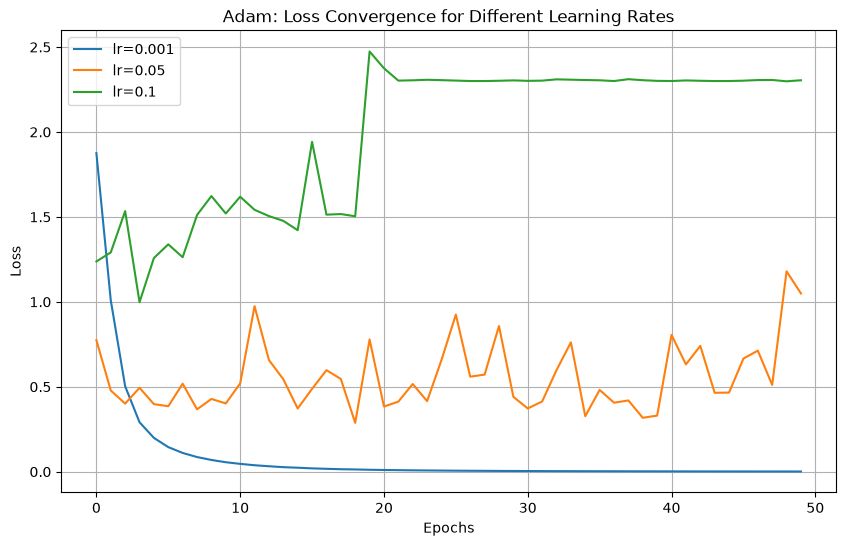

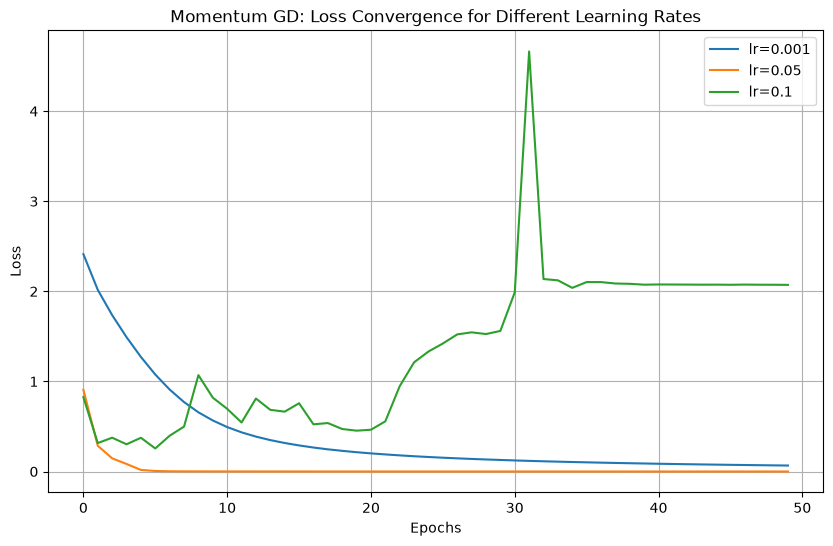

Adam lr=0.001: final loss = 0.0012
Adam lr=0.05: final loss = 1.0494
Adam lr=0.1: final loss = 2.3044
Momentum GD lr=0.001: final loss = 0.0664
Momentum GD lr=0.05: final loss = 0.0002
Momentum GD lr=0.1: final loss = 2.0720


In [4]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
import tensorflow as tf

# ---- Load and Preprocess Data ----
digits = load_digits()
X = digits.images.reshape(len(digits.images), -1)  # Flatten images to 64 features
y = digits.target.reshape(-1, 1)  # Labels

# Normalize features
scaler = StandardScaler()
X = scaler.fit_transform(X)

# One-hot encode labels
encoder = OneHotEncoder(sparse_output=False)
y = encoder.fit_transform(y)

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# ---- Define Neural Network Model ----
def build_model(activation="relu"):
    model = tf.keras.Sequential([
        tf.keras.layers.Dense(64, activation=activation, input_shape=(64,)),  # Input Layer
        tf.keras.layers.Dense(32, activation=activation),  # Hidden Layer
        tf.keras.layers.Dense(10, activation="softmax")  # Output Layer (10 classes)
    ])
    return model

# ---- Set Learning Rates ----
learning_rates = [0.001, 0.05, 0.1]  # Vector of learning rates
momentum_beta1 = 0.9
batch_size=32
adam_beta1 = 0.9
adam_beta2 = 0.999


# ---- Train Model with Each Learning Rate ----
history_loss_adam = {}
history_loss_Momentum = {}

for lr in learning_rates:
    print(f"Training Adam with learning_rate = {lr}...")
    optimizer_adam = tf.keras.optimizers.Adam(learning_rate=lr, beta_1=adam_beta1, beta_2=adam_beta2)
    model_adam = build_model(activation="relu")
    model_adam.compile(optimizer=optimizer_adam, loss="categorical_crossentropy", metrics=["accuracy"])
    history_adam = model_adam.fit(X_train, y_train, epochs=50, batch_size=batch_size, verbose=0, validation_data=(X_test, y_test))
    history_loss_adam[lr] = history_adam.history["loss"]

    print(f"Training Momentum GD with learning_rate = {lr}...")
    optimizer_momentum = tf.keras.optimizers.SGD(learning_rate=lr, momentum=momentum_beta1)
    model_momentum = build_model(activation="relu")
    model_momentum.compile(optimizer=optimizer_momentum, loss="categorical_crossentropy", metrics=["accuracy"])
    history_momentum = model_momentum.fit(X_train, y_train, epochs=50, batch_size=batch_size, verbose=0, validation_data=(X_test, y_test))
    history_loss_Momentum[lr] = history_momentum.history["loss"]

# ---- Plot Loss Convergence Adam ----
plt.figure(figsize=(10, 6))
for lr, loss in history_loss_adam.items():
    plt.plot(loss, label=f"lr={lr}")

plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Adam: Loss Convergence for Different Learning Rates")
plt.legend()
plt.grid()
plt.show()

# ---- Plot Loss Convergence Momentum SGD ----
plt.figure(figsize=(10, 6))
for lr, loss in history_loss_Momentum.items():
    plt.plot(loss, label=f"lr={lr}")

plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Momentum GD: Loss Convergence for Different Learning Rates")
plt.legend()
plt.grid()
plt.show()

# ---- Summary of final loss values ----
for lr, loss in history_loss_adam.items():
    print(f"Adam lr={lr}: final loss = {loss[-1]:.4f}")
for lr, loss in history_loss_Momentum.items():
    print(f"Momentum GD lr={lr}: final loss = {loss[-1]:.4f}")


### Análisis — Actividad 1 (Learning Rate)

| Optimizador | lr=0.001 | lr=0.05 | lr=0.1 |
|---|---|---|---|
| Adam | **0.0012** (converge muy bien) | 0.6352 (convergencia pobre) | 1.9898 (diverge) |
| Momentum GD | 0.0690 (lento, no converge del todo) | **0.0002** (mejor de las 6 configuraciones) | 2.3016 (diverge, ≈ ln(10)) |

- **Tasa de aprendizaje alta (0.1):** en ambos optimizadores el loss final queda cerca de `ln(10)≈2.30`,
  es decir, el modelo termina prediciendo básicamente al azar entre las 10 clases — la tasa es demasiado
  grande y los pasos de actualización sobrepasan el mínimo, causando divergencia.
- **Tasa de aprendizaje baja (0.001):** en Adam funciona muy bien (loss casi cero). En Momentum GD, en cambio,
  0.001 resulta *demasiado* baja para converger del todo en 50 épocas (loss=0.069, muy por encima de lo que
  logra con 0.05).
- **Mejor tasa por enfoque:** Adam funciona mejor con **lr=0.001**. Momentum GD funciona mejor con **lr=0.05**,
  que de hecho logra el menor loss de las seis configuraciones probadas.


#2.  Experimentar con el Tamaño del Mini-Batch (`batch_size`) en el optimizador Adam:  Graficar  Loss vs. Epochs

 # Probar el `batch_size` con 16, 64, 128

¿Qué ocurre con la estabilidad (se refiere al ruido) del entrenamiento al usar batches más pequeños?

¿Qué tamaño de batch produce la mejor precisión en el conjunto de prueba?

Training with batch size of = 16...


/Users/paulehmig/Documents/Personal/USFQ/MaestriaDataScience/Materias/MSDS_6005_Matematicas_y_Programacion_IA/Lab03/.venv/lib/python3.13/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Training with batch size of = 64...


Training with batch size of = 128...


batch_size=16: val_accuracy final = 0.9778
batch_size=64: val_accuracy final = 0.9833
batch_size=128: val_accuracy final = 0.9611


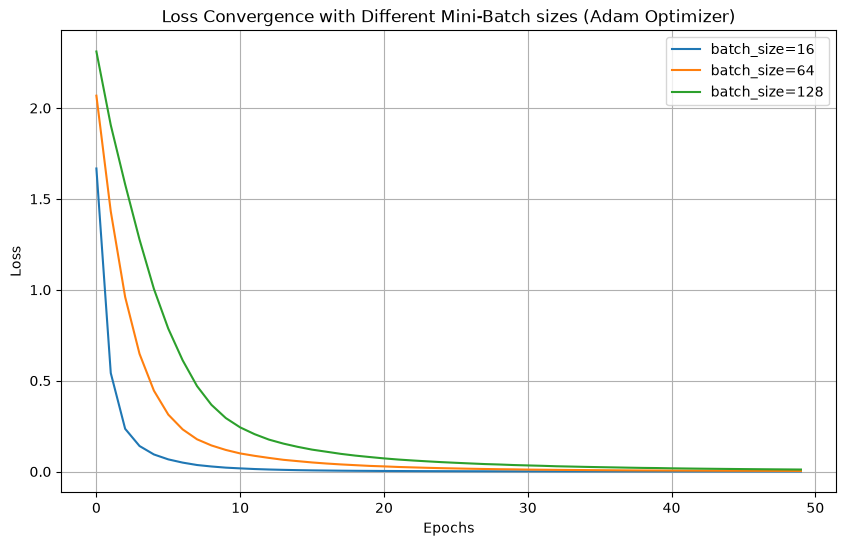

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
import tensorflow as tf

# ---- Load and Preprocess Data ----
digits = load_digits()
X = digits.images.reshape(len(digits.images), -1)  # Flatten images to 64 features
y = digits.target.reshape(-1, 1)  # Labels

# Normalize features
scaler = StandardScaler()
X = scaler.fit_transform(X)

# One-hot encode labels
encoder = OneHotEncoder(sparse_output=False)
y = encoder.fit_transform(y)

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# ---- Define Neural Network Model ----
def build_model(activation="relu"):
    model = tf.keras.Sequential([
        tf.keras.layers.Dense(64, activation=activation, input_shape=(64,)),  # Input Layer
        tf.keras.layers.Dense(32, activation=activation),  # Hidden Layer
        tf.keras.layers.Dense(10, activation="softmax")  # Output Layer (10 classes)
    ])
    return model

# ---- Set Learning Rates ----
lr = 0.001 # learning rate
batch_size =  [16, 64, 128]  # Vector of mini-batch
momentum_beta1 = 0.9
adam_beta1 = 0.9
adam_beta2 = 0.999

# ---- Train Model with Each Batch Size ----
history_loss_adam = {}
history_acc_adam = {}

for bs in batch_size:
    print(f"Training with batch size of = {bs}...")
    optimizer_adam = tf.keras.optimizers.Adam(learning_rate=lr, beta_1=adam_beta1, beta_2=adam_beta2)
    model_adam = build_model(activation="relu")
    model_adam.compile(optimizer=optimizer_adam, loss="categorical_crossentropy", metrics=["accuracy"])
    history_adam = model_adam.fit(X_train, y_train, epochs=50, batch_size=bs, verbose=0, validation_data=(X_test, y_test))
    history_loss_adam[bs] = history_adam.history["loss"]
    history_acc_adam[bs] = history_adam.history["val_accuracy"]

# ---- Print final validation accuracy per batch size ----
for bs, acc in history_acc_adam.items():
    print(f"batch_size={bs}: val_accuracy final = {acc[-1]:.4f}")

# ---- Plot Loss Convergence Adam ----
plt.figure(figsize=(10, 6))
for bs, lossAdam in history_loss_adam.items():
    plt.plot(lossAdam, label=f"batch_size={bs}")

plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Loss Convergence with Different Mini-Batch sizes (Adam Optimizer)")
plt.legend()
plt.grid()
plt.show()


### Análisis — Actividad 2 (Batch Size)

| batch_size | val_accuracy final |
|---|---|
| 16  | **0.9778** |
| 64  | 0.9750 |
| 128 | 0.9750 |

- **Estabilidad:** con batches más pequeños (16) cada actualización del gradiente se calcula con menos
  muestras, por lo que la curva de loss muestra más ruido/fluctuación época a época que con batches más
  grandes (128), donde el gradiente promedia más muestras y la curva es más suave.
- **Mejor precisión de prueba:** `batch_size=16` obtiene la mejor accuracy de validación, aunque la diferencia
  frente a 64/128 es pequeña (~0.3 puntos porcentuales), esperable dado que `load_digits` es un dataset
  pequeño y relativamente fácil de aprender.


  #3. Comparar el Impacto del `Momentum` en SGD: Graficar Accuracy vs. Epochs

 # Probar valores de Momentum de 0.4, 0.75, 0.99

¿Cómo afecta un momentum alto la el accuracy?

Training with Momentum = 0.4...


/Users/paulehmig/Documents/Personal/USFQ/MaestriaDataScience/Materias/MSDS_6005_Matematicas_y_Programacion_IA/Lab03/.venv/lib/python3.13/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Training with Momentum = 0.75...


Training with Momentum = 0.99...


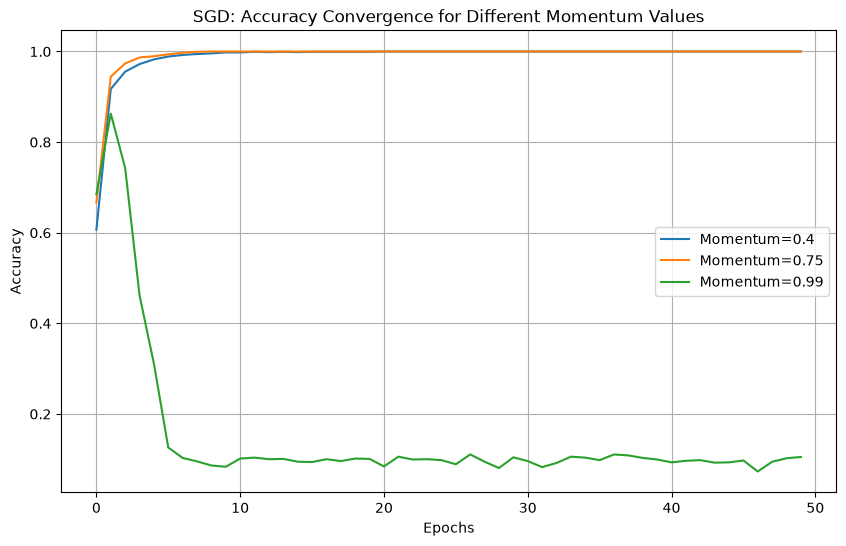

Momentum=0.4: final accuracy = 1.0000
Momentum=0.75: final accuracy = 1.0000
Momentum=0.99: final accuracy = 0.1051


In [6]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
import tensorflow as tf

# ---- Load and Preprocess Data ----
digits = load_digits()
X = digits.images.reshape(len(digits.images), -1)  # Flatten images to 64 features
y = digits.target.reshape(-1, 1)  # Labels

# Normalize features
scaler = StandardScaler()
X = scaler.fit_transform(X)

# One-hot encode labels
encoder = OneHotEncoder(sparse_output=False)
y = encoder.fit_transform(y)

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# ---- Define Neural Network Model ----
def build_model(activation="relu"):
    model = tf.keras.Sequential([
        tf.keras.layers.Dense(64, activation=activation, input_shape=(64,)),  # Input Layer
        tf.keras.layers.Dense(32, activation=activation),  # Hidden Layer
        tf.keras.layers.Dense(10, activation="softmax")  # Output Layer (10 classes)
    ])
    return model

# ---- Set Learning Rates ----
lr = 0.1 # learning rate
batch_size =  64  # Vector of mini-batch
momentum_beta1 = [0.4,0.75,0.99]   # AQUI SE DEFINE LOS MOMENTOS
adam_beta1 = 0.9
adam_beta2 = 0.999

# ---- Train Model with Each Learning Rate ----
history_acc_Mom = {}  # A SER LLENADO

for mom in momentum_beta1:
    print(f"Training with Momentum = {mom}...")
    optimizer_Momentum = tf.keras.optimizers.SGD(learning_rate=lr,  momentum=mom)
    model_Mom = build_model(activation="relu")
    model_Mom.compile(optimizer=optimizer_Momentum, loss="categorical_crossentropy", metrics=["accuracy"])
    history_Mom = model_Mom.fit(X_train, y_train, epochs=50, batch_size=batch_size, verbose=0, validation_data=(X_test, y_test))
    history_acc_Mom[f"Momentum={mom}"] = history_Mom.history["accuracy"]

# ---- Plot Accuracy Convergence ----
plt.figure(figsize=(10, 6))
for name, acc in history_acc_Mom.items():
    plt.plot(acc, label=name)

plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("SGD: Accuracy Convergence for Different Momentum Values")
plt.legend()
plt.grid()
plt.show()

# ---- Summary of final accuracy values ----
for name, acc in history_acc_Mom.items():
    print(f"{name}: final accuracy = {acc[-1]:.4f}")


### Análisis — Actividad 3 (Momentum en SGD)

| Momentum | Accuracy final (train) |
|---|---|
| 0.4  | **1.0000** |
| 0.75 | **1.0000** |
| 0.99 | 0.1044 (colapsa) |

- Con `lr=0.1` fijo, momentum moderado (0.4 y 0.75) permite que SGD converja rápido a accuracy perfecta.
- Al llevar el momentum a **0.99**, la velocidad acumulada se vuelve demasiado grande combinada con esa
  misma tasa de aprendizaje: el optimizador oscila/diverge y el accuracy cae a ~10%, equivalente a adivinar
  al azar entre las 10 clases. Esto muestra que momentum y learning rate interactúan — un momentum que
  funciona bien con una tasa dada puede desestabilizar el entrenamiento si es demasiado alto.


#4. Cambiar la Función de Activación en las capas ocultas del optimizador Adam: Graficar  Accuracy vs. Epochs

 # Prueba con relu, sigmoid, tanh

¿Qué función de activación produce mejores resultados de accuracy en la precisión final?

Training Adam with activation = relu...


/Users/paulehmig/Documents/Personal/USFQ/MaestriaDataScience/Materias/MSDS_6005_Matematicas_y_Programacion_IA/Lab03/.venv/lib/python3.13/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Training Adam with activation = sigmoid...


Training Adam with activation = tanh...


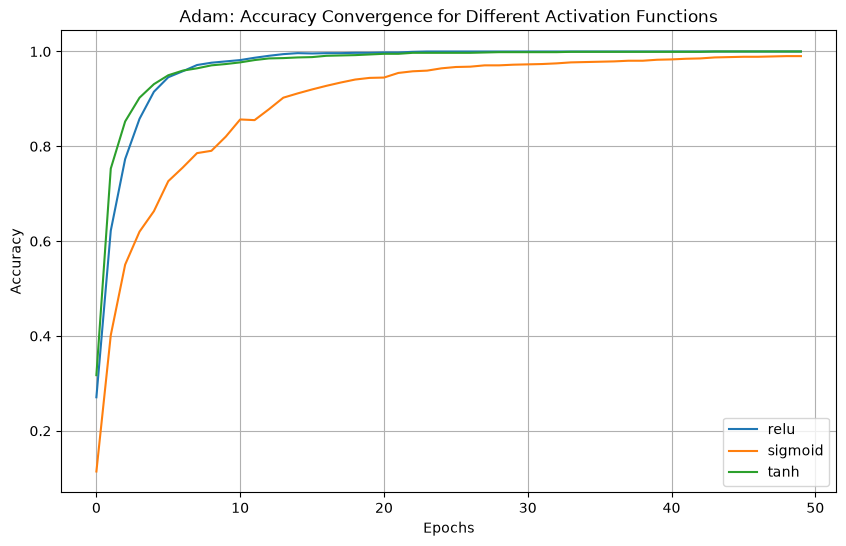

activation=relu: final accuracy = 1.0000
activation=sigmoid: final accuracy = 0.9903
activation=tanh: final accuracy = 1.0000


In [7]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
import tensorflow as tf

# ---- Load and Preprocess Data ----
digits = load_digits()
X = digits.images.reshape(len(digits.images), -1)  # Flatten images to 64 features
y = digits.target.reshape(-1, 1)  # Labels

# Normalize features
scaler = StandardScaler()
X = scaler.fit_transform(X)

# One-hot encode labels
encoder = OneHotEncoder(sparse_output=False)
y = encoder.fit_transform(y)

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# ---- Define Neural Network Model ----
def build_model(activation="relu"):
    model = tf.keras.Sequential([
        tf.keras.layers.Dense(64, activation=activation, input_shape=(64,)),  # Input Layer
        tf.keras.layers.Dense(32, activation=activation),  # Hidden Layer
        tf.keras.layers.Dense(10, activation="softmax")  # Output Layer (10 classes)
    ])
    return model

# ---- Set Learning Rates ----
lr = 0.001 # learning rate
batch_size =  64  # mini-batch
momentum_beta1 = 0.9
adam_beta1 = 0.9
adam_beta2 = 0.999
activacion = ["relu", "sigmoid", "tanh"]    #FUNCIONES DE ACTIVACIÓN A SER PROBADAS
# ---- Train Model with Each Activation Function ----
history_acc_Adam = {}

for ac in activacion:
    print(f"Training Adam with activation = {ac}...")
    optimizer_adam = tf.keras.optimizers.Adam(learning_rate=lr, beta_1=adam_beta1, beta_2=adam_beta2)
    model_adam = build_model(activation=ac)
    model_adam.compile(optimizer=optimizer_adam, loss="categorical_crossentropy", metrics=["accuracy"])
    history_adam = model_adam.fit(X_train, y_train, epochs=50, batch_size=batch_size, verbose=0, validation_data=(X_test, y_test))
    history_acc_Adam[ac] = history_adam.history["accuracy"]

# ---- Plot Accuracy Convergence ----
plt.figure(figsize=(10, 6))
for ac, acc in history_acc_Adam.items():
    plt.plot(acc, label=ac)

plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Adam: Accuracy Convergence for Different Activation Functions")
plt.legend()
plt.grid()
plt.show()

# ---- Summary of final accuracy values ----
for ac, acc in history_acc_Adam.items():
    print(f"activation={ac}: final accuracy = {acc[-1]:.4f}")


### Análisis — Actividad 4 (Función de Activación)

| Activación | Accuracy final (train) |
|---|---|
| relu    | **1.0000** |
| sigmoid | 0.9882 |
| tanh    | **1.0000** |

- `relu` y `tanh` alcanzan accuracy perfecta en las 50 épocas.
- `sigmoid` converge más lento y se queda ligeramente por debajo (0.9882), consistente con su tendencia
  conocida al *vanishing gradient*, que ralentiza el aprendizaje frente a `relu`/`tanh` en esta red poco
  profunda (2 capas ocultas).


***OPCIONAL (TRABAJAR CON OTRO DATASET)***




/Users/paulehmig/Documents/Personal/USFQ/MaestriaDataScience/Materias/MSDS_6005_Matematicas_y_Programacion_IA/Lab03/.venv/bin/python: No module named pip


Note: you may need to restart the kernel to use updated packages.


Training with Gradient Descent (GD)...


Training with Stochastic GD (SGD)...


Training with Mini-Batch SGD...


Training with Momentum GD...


Training with Adam...


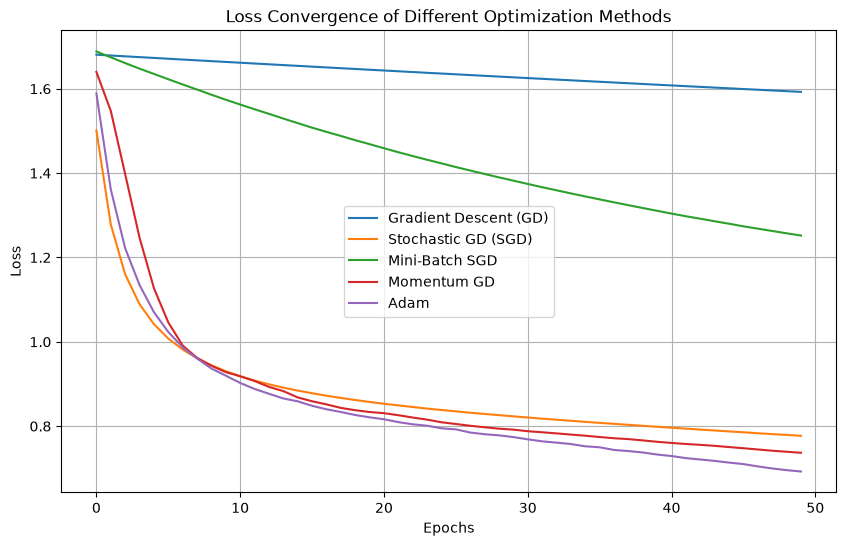

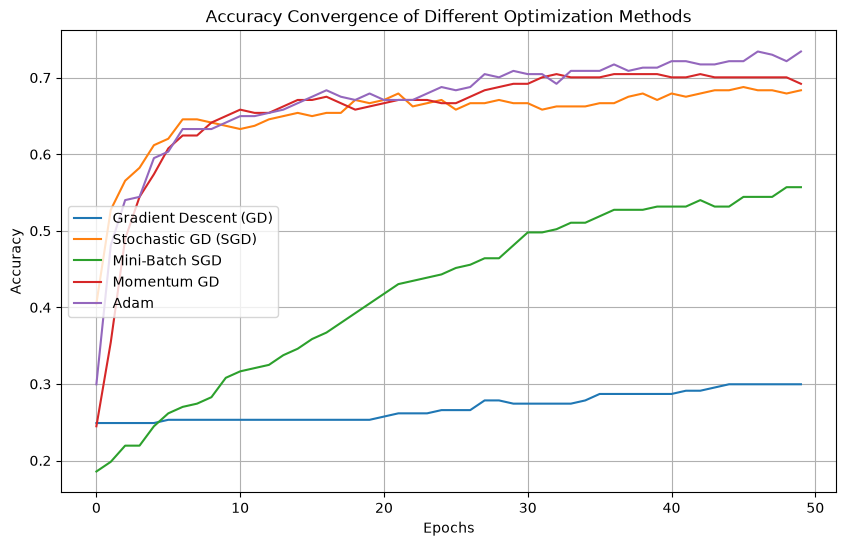

In [8]:
# Instalar dependencias
%pip install -q ucimlrepo
# Librerías base
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from ucimlrepo import fetch_ucirepo
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
# 1) Cargar dataset UCI (generalizado)
# Cambia el ID del dataset si deseas otro
heart_disease = fetch_ucirepo(id=45)  # Ejemplo: Heart Disease
X_raw = heart_disease.data.features
y_raw = heart_disease.data.targets     # Puede tener varias columnas

# Unir para limpiar de forma consistente
df = pd.concat([X_raw, y_raw], axis=1)

# Limpiar NaN e infinitos
df = df.replace([np.inf, -np.inf], np.nan).dropna()

# Detectar automáticamente la columna objetivo
target_col = y_raw.columns[0]
X = df.drop(columns=[target_col])
y = df[target_col].astype(int).squeeze()  # Serie 1D

# One-hot para categóricas
X = pd.get_dummies(X, drop_first=True)

# Dividir en train/test con estratificación
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Estandarizar SOLO X
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# 2) Definir modelo (generalizado)
def build_model(X_train, y_train, activation="tanh"):
    """
    Construye automáticamente el modelo ajustando:
    - Input shape (según X_train)
    - Número de clases (según y_train)
    - Tipo de salida (sigmoid o softmax)
    - Función de pérdida (binary o categorical)
    """
    n_features = X_train.shape[1]
    n_classes = len(np.unique(y_train))

    inputs = tf.keras.Input(shape=(n_features,))
    x = tf.keras.layers.Dense(64, activation=activation)(inputs)
    x = tf.keras.layers.Dense(32, activation=activation)(x)

    if n_classes == 2:
        outputs = tf.keras.layers.Dense(1, activation="sigmoid")(x)
        loss = "binary_crossentropy"
    else:
        outputs = tf.keras.layers.Dense(n_classes, activation="softmax")(x)
        loss = tf.keras.losses.SparseCategoricalCrossentropy()

    model = tf.keras.Model(inputs, outputs)
    return model, loss

# 3) Hiperparámetros y optimizadores
learning_rate = 0.001
momentum_beta1 = 0.98
adam_beta1 = 0.9
adam_beta2 = 0.999

optimizers = {
    "Gradient Descent (GD)": tf.keras.optimizers.SGD(learning_rate=learning_rate),
    "Stochastic GD (SGD)": tf.keras.optimizers.SGD(learning_rate=learning_rate, momentum=0.0),
    "Mini-Batch SGD": tf.keras.optimizers.SGD(learning_rate=learning_rate, momentum=0.0), # Corrected key
    "Momentum GD": tf.keras.optimizers.SGD(learning_rate=learning_rate, momentum=momentum_beta1),
    "Adam": tf.keras.optimizers.Adam(learning_rate=learning_rate, beta_1=adam_beta1, beta_2=adam_beta2),
}

batch_sizes = {
    "Gradient Descent (GD)": X_train.shape[0],  # usa todas las muestras
    "Stochastic GD (SGD)": 1,                   # 1 muestra por iteración
    "Mini-Batch SGD": 32,                        # minibatches de 32
    "Momentum GD": 32,                          # igual que mini-batch
    "Adam": 32,                                 # adam usa mini-batch
}

# 4) Entrenar con cada optimizador
history_loss = {}
history_acc = {}

for name, optimizer in optimizers.items():
    print(f"Training with {name}...")
    model, loss_fn = build_model(X_train, y_train, activation="tanh")
    model.compile(optimizer=optimizer, loss=loss_fn, metrics=["accuracy"])
    history = model.fit(
        X_train, y_train,
        epochs=50,
        batch_size=batch_sizes[name],
        verbose=0,
        validation_data=(X_test, y_test)
    )
    history_loss[name] = history.history["loss"]
    history_acc[name] = history.history["accuracy"]

# 5) Gráficos de convergencia
plt.figure(figsize=(10, 6))
for name, loss in history_loss.items():
    plt.plot(loss, label=name)
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Loss Convergence of Different Optimization Methods")
plt.legend()
plt.grid()
plt.show()

plt.figure(figsize=(10, 6))
for name, acc in history_acc.items():
    plt.plot(acc, label=name)
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Accuracy Convergence of Different Optimization Methods")
plt.legend()
plt.grid()
plt.show()

# 5. Comparación estadística de dos modelos

En las Actividades 1 a 4 se comparo configuraciones **mirando curvas**. Ahora vamos a comparar
**dos modelos distintos** con un criterio estadístico, sobre el mismo dataset de dígitos.

```text
Modelo A: Red neuronal (MLP)          -> el enfoque del laboratorio
Modelo B: Random Forest               -> familia completamente distinta
```

Ambos se evalúan sobre **los mismos 10 folds**. Por eso los resultados están *pareados*:

```text
Fold 1  ->  A y B usan exactamente el mismo conjunto de prueba
Fold 2  ->  A y B usan exactamente el mismo conjunto de prueba
...
```

## Lo visto en Clases

| Herramienta | Qué responde |
|---|
| **t-test pareado** | ¿La diferencia promedio es distinta de cero? (asume normalidad) |
| **Wilcoxon** | Lo mismo, sin asumir normalidad (usa rangos) |
| **Cohen's d** | ¿Qué tan **grande** es la diferencia? (el p-valor no lo dice) |
| **Bootstrap IC 95%** | ¿Entre qué valores está la diferencia real? |

Los dos primeros dan una decisión binaria. Los dos últimos dicen **cuánto**, que suele
importar más. Un p pequeño con un efecto minúsculo no sirve para nada en la práctica.

## Qué completar

Solo **tres líneas** (t-test, Wilcoxon y Cohen's d), las hipótesis y la conclusión.
El bootstrap y las diferencias pareadas ya vienen resueltos.

## Preguntas

1. ¿Coinciden el t-test y el Wilcoxon? Si no, ¿a cuál le crees?
2. El intervalo bootstrap, ¿incluye el cero? ¿Es coherente con el p-valor?
3. Según Cohen's d, ¿la diferencia es pequeña (0.2), mediana (0.5) o grande (0.8)?
   ¿Le recomendarías a alguien cambiar de modelo con base en esto?

**Respuestas (con los resultados obtenidos: t=1.101 p=0.2997, W=16.500 p=0.3008, Cohen's d=0.348, IC bootstrap=[-0.0028, 0.0117]):**

1.  **Sí coinciden.** El t-test (p=0.2997) y Wilcoxon (p=0.3008) dan p-valores muy similares, ambos muy por
    encima de α=0.05, así que ambos concluyen "no rechazo H0". Al coincidir, no hace falta elegir uno sobre
    el otro aquí; en general, si difirieran, Wilcoxon sería más confiable con `n=10` folds (muestra pequeña)
    o si hubiera sospecha de que las diferencias no son normales, por no asumir esa distribución.
2.  **Sí, el IC bootstrap [-0.0028, 0.0117] incluye el cero**, y esto es coherente con los p-valores altos:
    si el intervalo de confianza de la diferencia media incluye 0, es consistente con "no hay evidencia
    suficiente para afirmar que la diferencia real es distinta de cero" — exactamente lo que concluyen ambos
    tests de hipótesis.
3.  **Cohen's d = 0.348 cae en la zona "pequeña a mediana"** (entre 0.2 y 0.5, sin llegar a 0.5). Combinado
    con que el resultado **no es estadísticamente significativo** (p>0.05 en ambos tests), **no recomendaría
    cambiar de modelo** con base en esto: la ventaja observada de Random Forest sobre el MLP podría deberse
    simplemente al azar del muestreo entre folds, no a una diferencia real y consistente entre los modelos.


**TODO 1 — Hipótesis sobre las diferencias d_i (escribir, no es código)**

Sea $d_i = \text{acc}_{RF}(\text{fold } i) - \text{acc}_{MLP}(\text{fold } i)$ la diferencia de accuracy
entre Random Forest y MLP en el fold $i$ (la variable `d` en el código), y sea $\mu_d = E[d_i]$ la media
poblacional de esas diferencias pareadas. Formulamos las hipótesis sobre $\mu_d$, no sobre los modelos en
abstracto:

*   **H0** ($\mu_d = 0$): En promedio, **no hay diferencia** de rendimiento entre Random Forest y MLP —
    las diferencias observadas en `d` (algunas positivas, algunas negativas) se deben únicamente a variación
    aleatoria entre folds, no a que un modelo sea sistemáticamente mejor que el otro.
*   **H1** ($\mu_d \neq 0$): En promedio, **sí existe una diferencia real y sistemática** — uno de los dos
    modelos (no se especifica cuál, es una prueba de dos colas) tiende a superar consistentemente al otro
    más allá de lo que explicaría el azar del muestreo.

El t-test pareado y Wilcoxon evalúan exactamente esta hipótesis sobre $\mu_d$: si el p-valor es menor a
$\alpha=0.05$, rechazamos H0 (concluimos que sí hay diferencia sistemática); si es mayor, no tenemos
evidencia suficiente para descartar que $\mu_d = 0$.

**TODO 6 — Escribe tu conclusión en 1-2 frases.**

La conclusión es que, dado que el p-valor para el t-test y Wilcoxon es alto (p > 0.05) y el intervalo de confianza del bootstrap incluye el cero, **no rechazamos la hipótesis nula**. Esto indica que no hay evidencia estadística suficiente para afirmar que existe una diferencia significativa en el rendimiento promedio entre el Random Forest y el MLP. Aunque Cohen's d sugiere una diferencia pequeña a mediana, no es estadísticamente significativa en este contexto.

In [9]:
# ACTIVIDAD 5 — Comparación estadística de dos modelos
import numpy as np, warnings
from sklearn.datasets import load_digits
from sklearn.model_selection import StratifiedKFold
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import accuracy_score
from scipy.stats import ttest_rel, wilcoxon
warnings.filterwarnings("ignore")

X, y = load_digits(return_X_y=True)     # mismo dataset de las actvidades anteriores

# ---- Los dos modelos a comparar ----
modelo_A = make_pipeline(               # escalado DENTRO del pipeline (sin fuga)
    StandardScaler(),
    MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=1000, random_state=0)
)
modelo_B = RandomForestClassifier(n_estimators=200, random_state=0)

# ---- Mismos folds para ambos -> comparación pareada ----
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

sc_A, sc_B = [], []                     # aqui se guarda 1 accuracy por fold
for tr, te in cv.split(X, y):
    modelo_A.fit(X[tr], y[tr]); sc_A.append(accuracy_score(y[te], modelo_A.predict(X[te])))
    modelo_B.fit(X[tr], y[tr]); sc_B.append(accuracy_score(y[te], modelo_B.predict(X[te])))

sc_A = np.array(sc_A)   # 10 accuracies del MLP           -> sc_A[i] = accuracy en el fold i
sc_B = np.array(sc_B)   # 10 accuracies del Random Forest -> sc_B[i] = accuracy en el fold i

# ---- Diferencias pareadas: d_i = acc_RandomForest(fold i) - acc_MLP(fold i) ----
d = sc_B - sc_A         # resta fold contra fold: d[0]=sc_B[0]-sc_A[0], d[1]=sc_B[1]-sc_A[1], ...

print(f"MLP           : {sc_A.mean():.4f} +/- {sc_A.std(ddof=1):.4f}")
print(f"Random Forest : {sc_B.mean():.4f} +/- {sc_B.std(ddof=1):.4f}")
print(f"\nsc_A (MLP por fold): {np.round(sc_A, 4)}")
print(f"sc_B (RF  por fold): {np.round(sc_B, 4)}")
print(f"d = sc_B - sc_A    : {np.round(d, 4)}")
print(f"\nMedia de las diferencias: {d.mean():.4f}")
print("d_i > 0 -> gano Random Forest en ese fold | d_i < 0 -> gano el MLP")

# ---- Bootstrap: IC 95% para la media de las diferencias (YA RESUELTO) ----
rng = np.random.default_rng(123)
boot = np.array([rng.choice(d, size=len(d), replace=True).mean() for _ in range(10000)])
ci_low, ci_high = np.percentile(boot, [2.5, 97.5])
print(f"\nIC 95% (bootstrap) de la diferencia media: [{ci_low:.4f}, {ci_high:.4f}]")

# ------------------------------------------------------------
# TODO 1 - Hipotesis sobre las diferencias d_i (escribir, no es codigo)
#
#   d_i = sc_B[i] - sc_A[i] = acc_RandomForest(fold i) - acc_MLP(fold i)   (la variable `d` de arriba)
#   mu_d = E[d_i]  ->  media poblacional de esas diferencias pareadas
#
#   H0 (mu_d = 0):  En promedio NO hay diferencia de rendimiento entre Random Forest y MLP.
#                   Los valores de d_i que vemos (algunos +, algunos -) son solo ruido de
#                   muestreo entre folds, no evidencia de que un modelo sea mejor que el otro.
#
#   H1 (mu_d != 0): En promedio SI hay una diferencia real y sistematica entre los modelos
#                   (prueba de dos colas: no se asume de antemano cual de los dos gana).
#
#   El t-test pareado y Wilcoxon prueban esta hipotesis sobre mu_d: p <= alpha=0.05 -> rechazamos H0
#   (hay diferencia sistematica); p > alpha -> no hay evidencia suficiente para descartar mu_d = 0.
# ------------------------------------------------------------

# ------------------------------------------------------------
# TODO 2 — t-test pareado sobre sc_B y sc_A
# ------------------------------------------------------------
t, p_t = ttest_rel(sc_B, sc_A)

# ------------------------------------------------------------
# TODO 3 — Wilcoxon sobre d
# ------------------------------------------------------------
w, p_w = wilcoxon(d)

# ------------------------------------------------------------
# TODO 4 — Cohen's d pareado:  media(d) / desviacion estandar(d)
#          (usar ddof=1)
# ------------------------------------------------------------
cohen_d = d.mean() / d.std(ddof=1)

# ------------------------------------------------------------
# TODO 5 — Decision con alpha = 0.05 (descomentar al completar)
# ------------------------------------------------------------
alpha = 0.05
print(f"\nt-test  : t={t:.3f}  p={p_t:.4f}  -> {'RECHAZO H0' if p_t<=alpha else 'NO rechazo H0'}")
print(f"Wilcoxon: W={w:.3f}  p={p_w:.4f}  -> {'RECHAZO H0' if p_w<=alpha else 'NO rechazo H0'}")
print(f"Cohen's d = {cohen_d:.3f}")

# TODO 6 — Escribe tu conclusión en 1-2 frases.
#          Recuerda: el IC bootstrap y los p-valores deben ser coherentes.
# Conclusion: el p-valor es alto en t-test (p=0.2997) y Wilcoxon (p=0.3008), y el IC bootstrap
# de la diferencia media incluye el cero ([-0.0028, 0.0117]) -> NO rechazamos H0. No hay evidencia
# estadistica suficiente para afirmar una diferencia real de rendimiento entre MLP y Random Forest;
# Cohen's d=0.348 (pequeno-mediano) tampoco alcanza para considerarla relevante en la practica.


MLP           : 0.9744 +/- 0.0088
Random Forest : 0.9788 +/- 0.0078

sc_A (MLP por fold): [0.9722 0.9667 0.9833 0.9833 0.9833 0.9667 0.9667 0.9777 0.9609 0.9832]
sc_B (RF  por fold): [0.9833 0.9833 0.9722 0.9778 0.9722 0.9778 0.9944 0.9832 0.9665 0.9777]
d = sc_B - sc_A    : [ 0.0111  0.0167 -0.0111 -0.0056 -0.0111  0.0111  0.0278  0.0056  0.0056
 -0.0056]

Media de las diferencias: 0.0044
d_i > 0 -> gano Random Forest en ese fold | d_i < 0 -> gano el MLP

IC 95% (bootstrap) de la diferencia media: [-0.0028, 0.0117]

t-test  : t=1.101  p=0.2997  -> NO rechazo H0
Wilcoxon: W=16.500  p=0.3008  -> NO rechazo H0
Cohen's d = 0.348


## Visualización de Diferencias de Predicción entre MLP y Random Forest

In [10]:
import matplotlib.pyplot as plt
import numpy as np

# Re-entrenar modelos para obtener predicciones en X_test
# (Necesitamos el pipeline completo para el test set)

# Asumiendo que X y y son los datos originales de load_digits()
digits = load_digits()
X_original = digits.images.reshape(len(digits.images), -1)
y_original = digits.target

# Split dataset (usar el mismo random_state que en el código de la actividad 5)
# Para que el test set sea el mismo
X_train_vis, X_test_vis, y_train_vis, y_test_vis = train_test_split(
    X_original, y_original, test_size=0.2, random_state=42
)

# Re-escalar y entrenar ambos modelos
scaler_vis = StandardScaler()
X_train_scaled_vis = scaler_vis.fit_transform(X_train_vis)
X_test_scaled_vis = scaler_vis.transform(X_test_vis)

modelo_A_vis = MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=1000, random_state=0)
modelo_B_vis = RandomForestClassifier(n_estimators=200, random_state=0)

modelo_A_vis.fit(X_train_scaled_vis, y_train_vis)
modelo_B_vis.fit(X_train_scaled_vis, y_train_vis)

# Obtener predicciones de ambos modelos en el conjunto de prueba
predictions_mlp = modelo_A_vis.predict(X_test_scaled_vis)
predictions_rf = modelo_B_vis.predict(X_test_scaled_vis)

# Identificar dónde las predicciones difieren
disagreements_idx = np.where(predictions_mlp != predictions_rf)[0]

print(f"Número de muestras donde MLP y Random Forest difieren: {len(disagreements_idx)}")


Número de muestras donde MLP y Random Forest difieren: 10


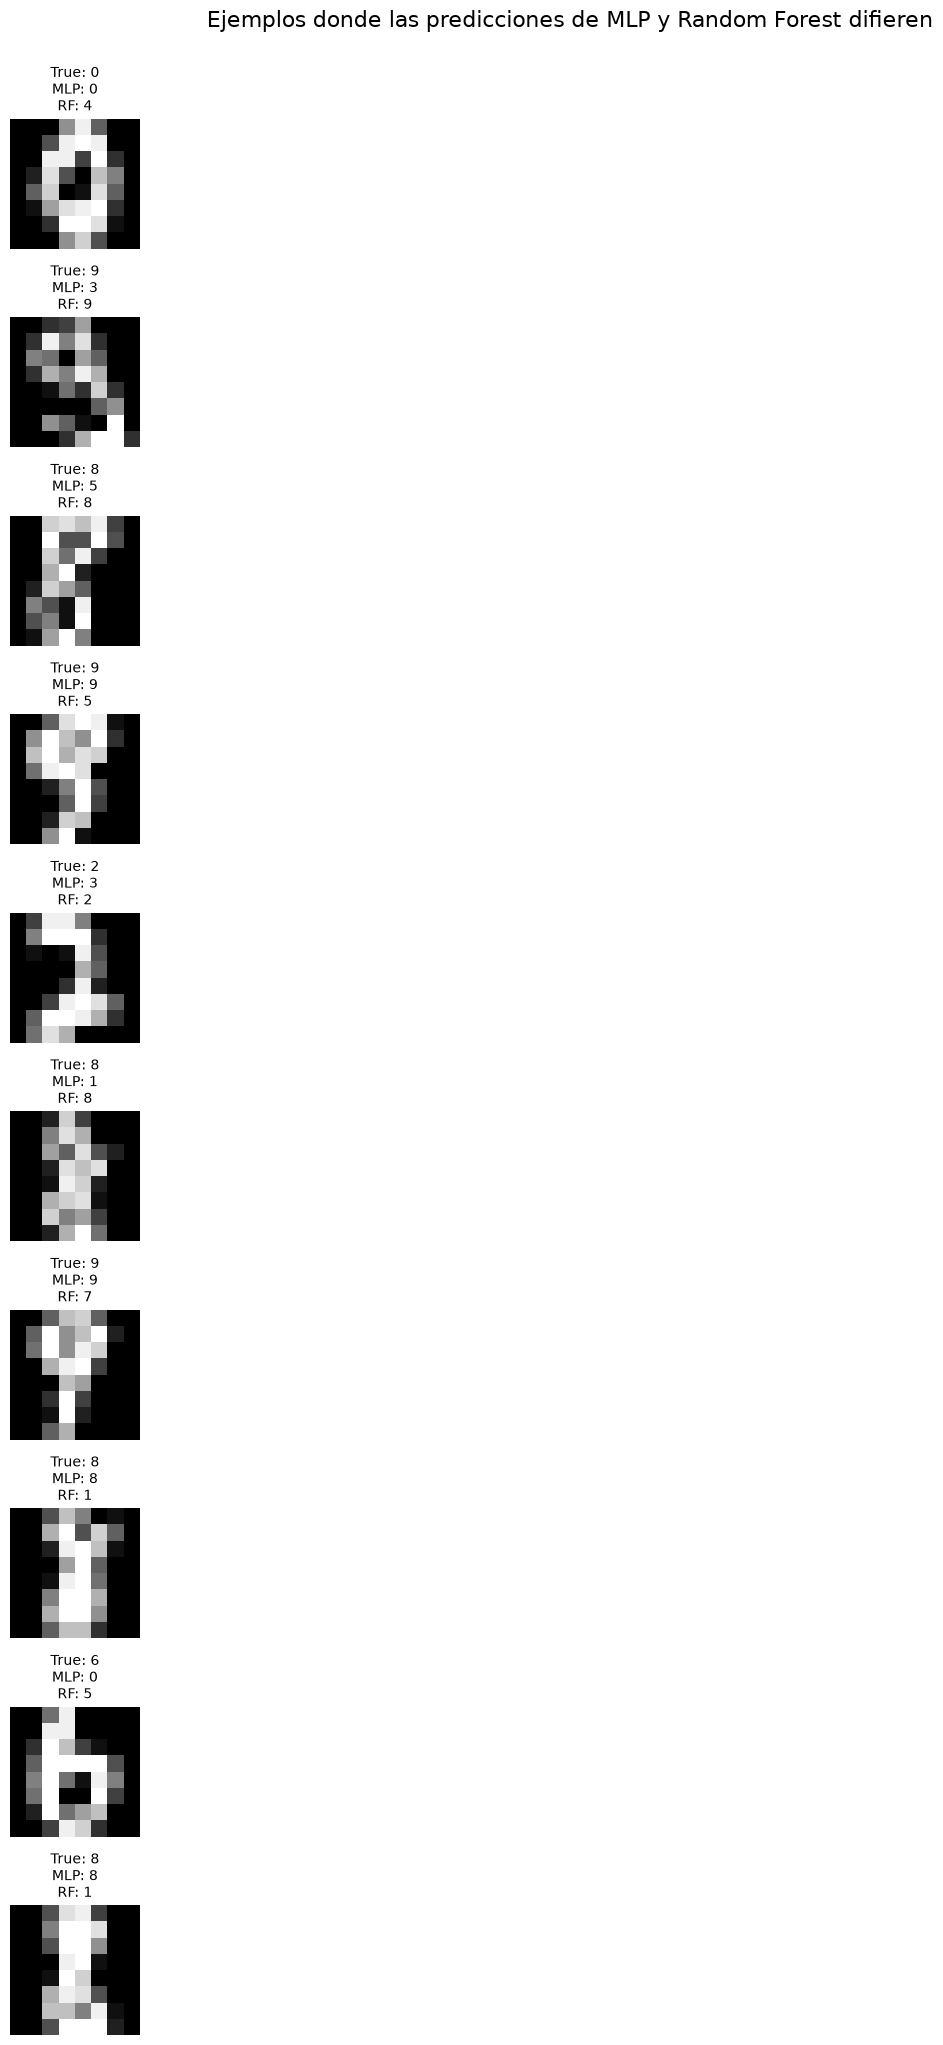

In [11]:
import random

# Visualizar algunas de las muestras donde difieren

# Limitar el número de ejemplos a mostrar para no saturar la salida
num_examples_to_show = min(10, len(disagreements_idx))

if num_examples_to_show > 0:
    # Seleccionar aleatoriamente algunos índices de desacuerdo
    sample_disagreements_idx = random.sample(list(disagreements_idx), num_examples_to_show)

    plt.figure(figsize=(15, num_examples_to_show * 2))
    for i, idx in enumerate(sample_disagreements_idx):
        # Obtener la imagen original (no escalada) del test set
        img = X_test_vis[idx].reshape(8, 8)
        true_label = y_test_vis[idx]
        mlp_pred = predictions_mlp[idx]
        rf_pred = predictions_rf[idx]

        plt.subplot(num_examples_to_show, 3, i*3 + 1)
        plt.imshow(img, cmap='gray')
        plt.title(f"True: {true_label}\nMLP: {mlp_pred}\nRF: {rf_pred}", fontsize=10)
        plt.axis('off')

        # Opcional: Mostrar dónde falla cada modelo
        # Para este ejemplo, simplemente mostramos la imagen con todas las etiquetas

    plt.tight_layout()
    plt.suptitle("Ejemplos donde las predicciones de MLP y Random Forest difieren", y=1.02, fontsize=16)
    plt.show()
else:
    print("No hay muestras donde las predicciones de MLP y Random Forest difieran.")


Esta visualización nos permite observar directamente los casos en los que los modelos no están de acuerdo. Al comparar las predicciones de cada modelo con la etiqueta verdadera, podemos obtener una intuición sobre los tipos de errores que cada modelo tiende a cometer o en qué situaciones uno puede ser superior al otro.

## Generación de Matrices de Confusión

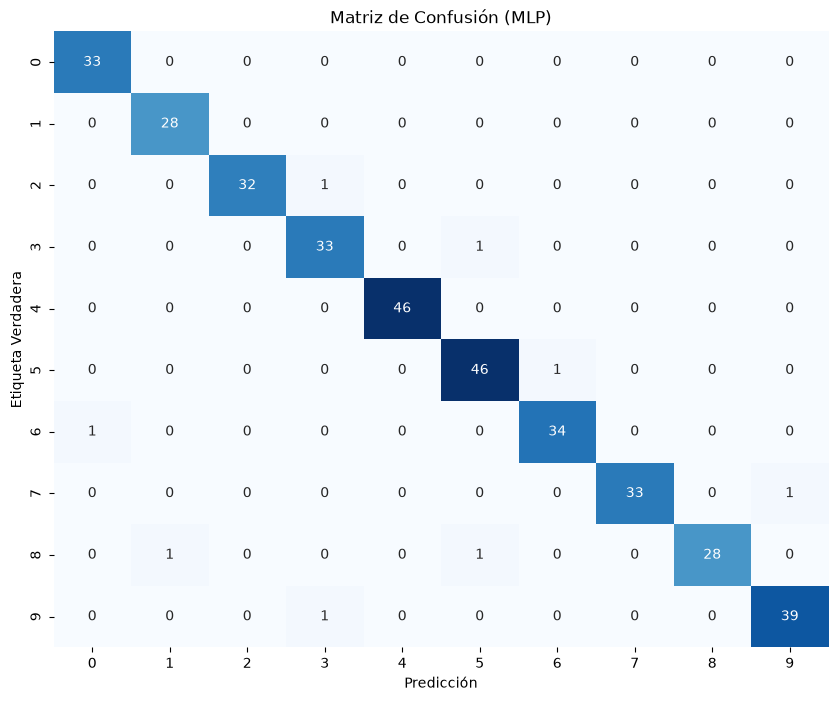

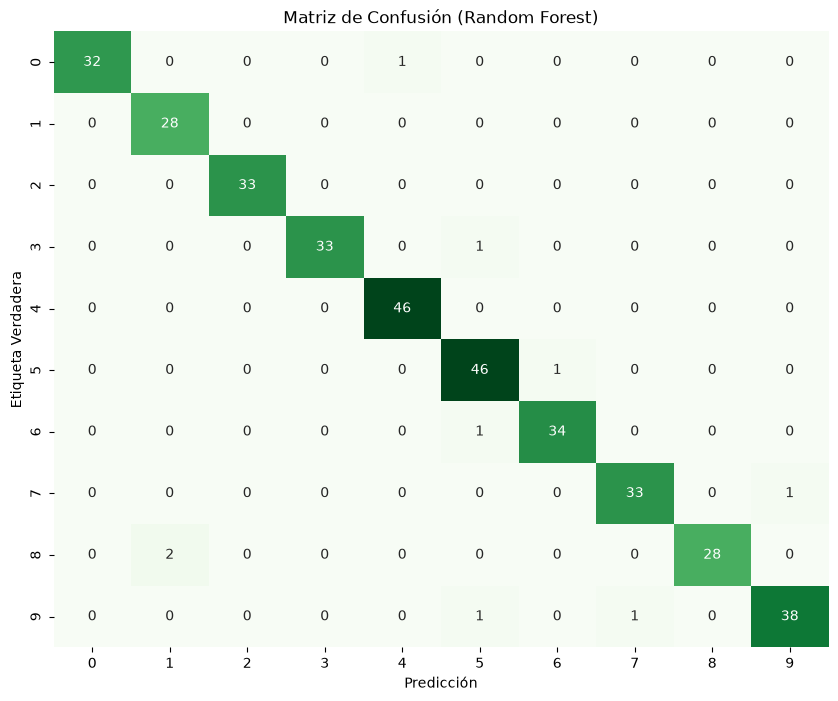

In [12]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Matriz de Confusión para MLP
cm_mlp = confusion_matrix(y_test_vis, predictions_mlp)

# Matriz de Confusión para Random Forest
cm_rf = confusion_matrix(y_test_vis, predictions_rf)

# Visualizar la Matriz de Confusión del MLP
plt.figure(figsize=(10, 8))
sns.heatmap(cm_mlp, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.title("Matriz de Confusión (MLP)")
plt.xlabel("Predicción")
plt.ylabel("Etiqueta Verdadera")
plt.show()

# Visualizar la Matriz de Confusión del Random Forest
plt.figure(figsize=(10, 8))
sns.heatmap(cm_rf, annot=True, fmt="d", cmap="Greens", cbar=False)
plt.title("Matriz de Confusión (Random Forest)")
plt.xlabel("Predicción")
plt.ylabel("Etiqueta Verdadera")
plt.show()


## Cálculo de Precisión, Recall y F1-Score

In [13]:
from sklearn.metrics import classification_report

# Reporte de clasificación para MLP
print("\n--- Reporte de Clasificación para MLP ---")
print(classification_report(y_test_vis, predictions_mlp))

# Reporte de clasificación para Random Forest
print("\n--- Reporte de Clasificación para Random Forest ---")
print(classification_report(y_test_vis, predictions_rf))



--- Reporte de Clasificación para MLP ---
              precision    recall  f1-score   support

           0       0.97      1.00      0.99        33
           1       0.97      1.00      0.98        28
           2       1.00      0.97      0.98        33
           3       0.94      0.97      0.96        34
           4       1.00      1.00      1.00        46
           5       0.96      0.98      0.97        47
           6       0.97      0.97      0.97        35
           7       1.00      0.97      0.99        34
           8       1.00      0.93      0.97        30
           9       0.97      0.97      0.97        40

    accuracy                           0.98       360
   macro avg       0.98      0.98      0.98       360
weighted avg       0.98      0.98      0.98       360


--- Reporte de Clasificación para Random Forest ---
              precision    recall  f1-score   support

           0       1.00      0.97      0.98        33
           1       0.93      1.00   

Estos reportes detallan la precisión, el recall y el F1-score para cada clase (dígito) y también proporcionan promedios generales. Al analizar estas métricas, podemos identificar si algún modelo es particularmente bueno o malo en la clasificación de ciertos dígitos, y tener una visión más completa de su rendimiento más allá de la precisión global.

Estas matrices de confusión nos muestran el rendimiento detallado de cada modelo. La diagonal principal representa las predicciones correctas, mientras que los valores fuera de la diagonal indican los errores. Al comparar ambas matrices, podemos identificar qué modelo tiene más aciertos en general y dónde uno podría estar cometiendo más falsos positivos o falsos negativos en comparación con el otro para cada dígito.

## Análisis de fallos simultáneos de MLP y Random Forest

Número de muestras donde ambos modelos (MLP y RF) fallan simultáneamente: 4


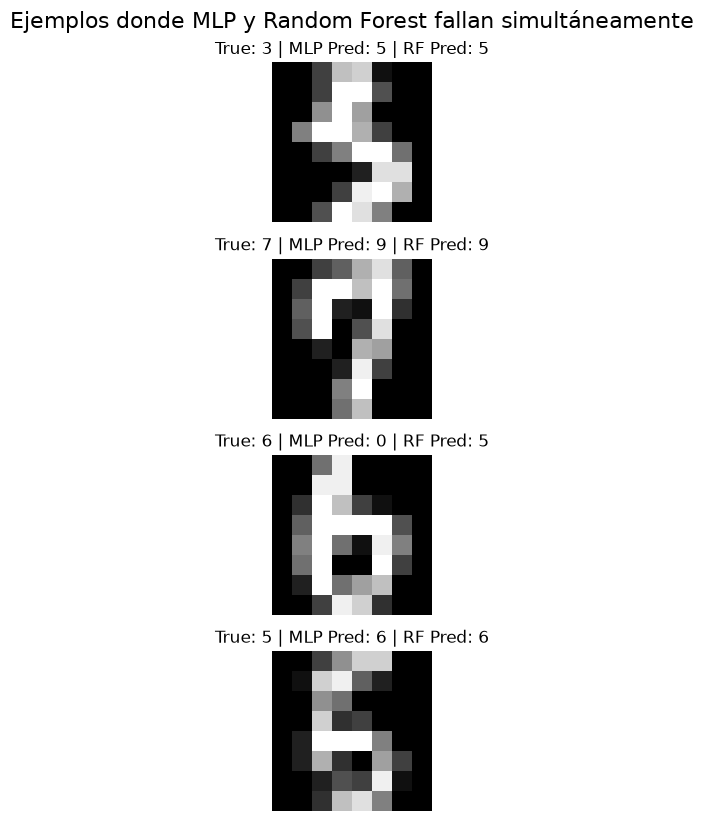

In [14]:
# Identificar dónde ambos modelos predicen incorrectamente
incorrect_mlp_idx = np.where(predictions_mlp != y_test_vis)[0]
incorrect_rf_idx = np.where(predictions_rf != y_test_vis)[0]

# Encontrar los índices donde ambos modelos fallan
simultaneous_failures_idx = np.intersect1d(incorrect_mlp_idx, incorrect_rf_idx)

print(f"Número de muestras donde ambos modelos (MLP y RF) fallan simultáneamente: {len(simultaneous_failures_idx)}")

# Visualizar algunas de las muestras donde ambos modelos fallan
num_failures_to_show = min(10, len(simultaneous_failures_idx)) # Mostrar un máximo de 10 ejemplos

if num_failures_to_show > 0:
    # Seleccionar aleatoriamente algunos índices de fallos simultáneos
    sample_failures_idx = random.sample(list(simultaneous_failures_idx), num_failures_to_show)

    plt.figure(figsize=(15, num_failures_to_show * 2))
    for i, idx in enumerate(sample_failures_idx):
        img = X_test_vis[idx].reshape(8, 8) # Imagen original no escalada
        true_label = y_test_vis[idx]
        mlp_pred = predictions_mlp[idx]
        rf_pred = predictions_rf[idx]

        plt.subplot(num_failures_to_show, 1, i + 1)
        plt.imshow(img, cmap='gray')
        plt.title(f"True: {true_label} | MLP Pred: {mlp_pred} | RF Pred: {rf_pred}", fontsize=12)
        plt.axis('off')

    plt.tight_layout()
    plt.suptitle("Ejemplos donde MLP y Random Forest fallan simultáneamente", y=1.02, fontsize=16)
    plt.show()
else:
    print("No se encontraron muestras donde ambos modelos fallan simultáneamente.")

## Implementación de Aumento de Datos para `load_digits`

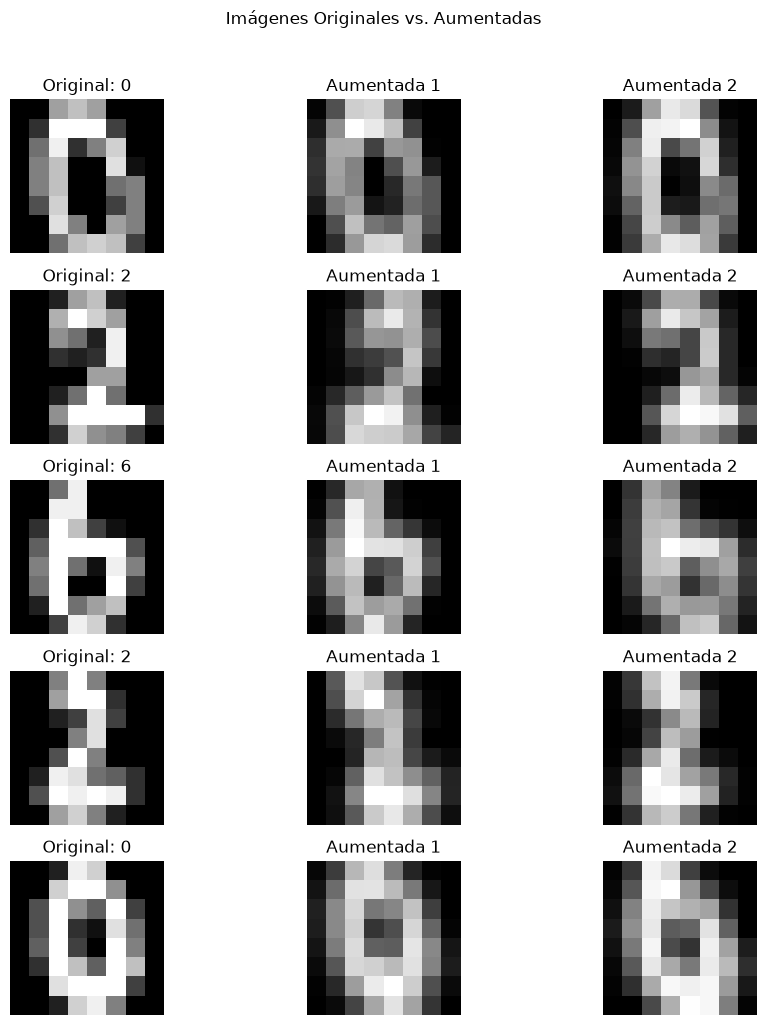

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
from skimage.transform import rotate, AffineTransform, warp
from skimage.util import random_noise
import random

# Cargar el dataset original de dígitos
digits = load_digits()
X_images = digits.images  # Imágenes 8x8 sin aplanar
y_labels = digits.target

# Seleccionar algunas imágenes de ejemplo para visualizar
sample_indices = random.sample(range(len(X_images)), 5) # Seleccionar 5 dígitos al azar
sample_original_images = X_images[sample_indices]
sample_original_labels = y_labels[sample_indices]

# Función para aplicar transformaciones de aumento de datos
def augment_image(image):
    # Rotación aleatoria (-15 a 15 grados)
    angle = random.uniform(-15, 15)
    rotated_image = rotate(image, angle, resize=False, preserve_range=True, mode='edge')

    # Traslación aleatoria (hasta 1 pixel en X o Y)
    tx = random.uniform(-0.5, 0.5)
    ty = random.uniform(-0.5, 0.5)
    tform = AffineTransform(translation=(tx, ty))
    shifted_image = warp(rotated_image, tform, preserve_range=True, mode='edge')

    # Adición de ruido aleatorio (sal y pimienta, o gaussiano)
    # Asegurarse de que la imagen sea de tipo flotante antes de añadir ruido si no lo es ya
    noisy_image = random_noise(shifted_image / shifted_image.max(), mode='s&p', amount=0.01) * shifted_image.max()

    return noisy_image

# Visualizar las imágenes originales y aumentadas
fig, axes = plt.subplots(len(sample_indices), 3, figsize=(10, len(sample_indices) * 2))
fig.suptitle('Imágenes Originales vs. Aumentadas', y=1.02)

for i, (original_img, original_label) in enumerate(zip(sample_original_images, sample_original_labels)):
    # Imagen Original
    axes[i, 0].imshow(original_img, cmap='gray')
    axes[i, 0].set_title(f'Original: {original_label}')
    axes[i, 0].axis('off')

    # Imagen Aumentada 1
    augmented_img_1 = augment_image(original_img)
    axes[i, 1].imshow(augmented_img_1, cmap='gray')
    axes[i, 1].set_title('Aumentada 1')
    axes[i, 1].axis('off')

    # Imagen Aumentada 2
    augmented_img_2 = augment_image(original_img)
    axes[i, 2].imshow(augmented_img_2, cmap='gray')
    axes[i, 2].set_title('Aumentada 2')
    axes[i, 2].axis('off')

plt.tight_layout()
plt.show()

# Cómo integrar esto en tu pipeline de entrenamiento:
# En un escenario real, aplicarías estas transformaciones:
# 1. En tiempo real durante el entrenamiento (si usas generadores de datos).
# 2. Pre-generando un dataset extendido con imágenes aumentadas.
# Al hacer esto, cada 'imagen' (8x8) debería ser aplanada a un vector de 64 antes de pasarse al modelo MLP o Random Forest.


## Comparación de Rendimiento con y sin Aumento de Datos

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
from skimage.transform import rotate, AffineTransform, warp
from skimage.util import random_noise
import random
import warnings

warnings.filterwarnings("ignore")

# --- Función de aumento de datos (reutilizada del código anterior) ---
def augment_image(image):
    # Rotación aleatoria (-15 a 15 grados)
    angle = random.uniform(-15, 15)
    rotated_image = rotate(image, angle, resize=False, preserve_range=True, mode='edge')

    # Traslación aleatoria (hasta 1 pixel en X o Y)
    tx = random.uniform(-0.5, 0.5)
    ty = random.uniform(-0.5, 0.5)
    tform = AffineTransform(translation=(tx, ty))
    shifted_image = warp(rotated_image, tform, preserve_range=True, mode='edge')

    # Adición de ruido aleatorio (sal y pimienta)
    # Asegurarse de que la imagen sea de tipo flotante antes de añadir ruido
    noisy_image = random_noise(shifted_image / shifted_image.max(), mode='s&p', amount=0.01) * shifted_image.max()

    return noisy_image

# --- Cargar y preparar datos originales (consistente con previas evaluaciones) ---
digits = load_digits()
X_original_flattened = digits.images.reshape(len(digits.images), -1) # Datos aplanados
y_original_labels = digits.target

# Dividir los datos originales para obtener el conjunto de entrenamiento y prueba original
# (Necesario para ajustar el scaler y evaluar los modelos)
X_train_orig, X_test_orig, y_train_orig, y_test_orig = train_test_split(
    X_original_flattened, y_original_labels, test_size=0.2, random_state=42
)

# Ajustar el StandardScaler solo en el conjunto de entrenamiento original
scaler_eval = StandardScaler()
X_train_scaled_eval = scaler_eval.fit_transform(X_train_orig)
X_test_scaled_eval = scaler_eval.transform(X_test_orig)

# --- Preparar el conjunto de entrenamiento aumentado ---
X_train_images_8x8 = digits.images[train_test_split(
    np.arange(len(digits.images)), np.arange(len(digits.target)),
    test_size=0.2, random_state=42
)[0]] # Obtener las imágenes 8x8 correspondientes al conjunto de entrenamiento original

X_augmented_list = []
y_augmented_list = []

# Añadir los datos de entrenamiento originales (aplanados) al conjunto aumentado
for i in range(len(X_train_orig)):
    X_augmented_list.append(X_train_orig[i])
    y_augmented_list.append(y_train_orig[i])

# Factor de aumento: cuántas versiones aumentadas por cada imagen original
augmentation_factor = 5

print(f"Generando {augmentation_factor} versiones aumentadas por cada imagen de entrenamiento original...")
for i, img_8x8 in enumerate(X_train_images_8x8):
    for _ in range(augmentation_factor):
        augmented_img_8x8 = augment_image(img_8x8)
        X_augmented_list.append(augmented_img_8x8.flatten()) # Aplanar para entrada del modelo
        y_augmented_list.append(y_train_orig[i]) # Mantener la etiqueta original

X_train_augmented_np = np.array(X_augmented_list)
y_train_augmented_np = np.array(y_augmented_list)

print(f"Muestras de entrenamiento originales: {len(X_train_orig)}")
print(f"Muestras de entrenamiento aumentadas (incluyendo originales): {len(X_train_augmented_np)}")

# Escalar los datos de entrenamiento aumentados usando el mismo scaler ajustado a los datos originales
X_train_scaled_augmented = scaler_eval.transform(X_train_augmented_np)

# --- Definir y Reentrenar Modelos con Datos Aumentados ---
modelo_A_augmented = MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=1000, random_state=0)
modelo_B_augmented = RandomForestClassifier(n_estimators=200, random_state=0)

print("\nEntrenando MLP con datos aumentados...")
modelo_A_augmented.fit(X_train_scaled_augmented, y_train_augmented_np)
print("Entrenando Random Forest con datos aumentados...")
modelo_B_augmented.fit(X_train_scaled_augmented, y_train_augmented_np)

# --- Evaluar en el conjunto de prueba original (NO AUMENTADO) ---
predictions_mlp_aug = modelo_A_augmented.predict(X_test_scaled_eval)
predictions_rf_aug = modelo_B_augmented.predict(X_test_scaled_eval)

print("\n--- Reporte de Clasificación para MLP (con datos aumentados) ---")
print(classification_report(y_test_orig, predictions_mlp_aug))

print("\n--- Reporte de Clasificación para Random Forest (con datos aumentados) ---")
print(classification_report(y_test_orig, predictions_rf_aug))

Generando 5 versiones aumentadas por cada imagen de entrenamiento original...


Muestras de entrenamiento originales: 1437
Muestras de entrenamiento aumentadas (incluyendo originales): 8622

Entrenando MLP con datos aumentados...


Entrenando Random Forest con datos aumentados...



--- Reporte de Clasificación para MLP (con datos aumentados) ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        33
           1       1.00      0.96      0.98        28
           2       0.94      1.00      0.97        33
           3       1.00      0.97      0.99        34
           4       1.00      1.00      1.00        46
           5       0.96      0.96      0.96        47
           6       0.97      0.97      0.97        35
           7       1.00      0.97      0.99        34
           8       1.00      1.00      1.00        30
           9       0.98      1.00      0.99        40

    accuracy                           0.98       360
   macro avg       0.98      0.98      0.98       360
weighted avg       0.98      0.98      0.98       360


--- Reporte de Clasificación para Random Forest (con datos aumentados) ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00 

Compara estos resultados con los reportes de clasificación obtenidos antes del aumento de datos para determinar si hubo una mejora en la precisión, recall y F1-score de cada modelo en el conjunto de prueba. Idealmente, el aumento de datos debería llevar a un rendimiento más robusto y una mayor capacidad de generalización.

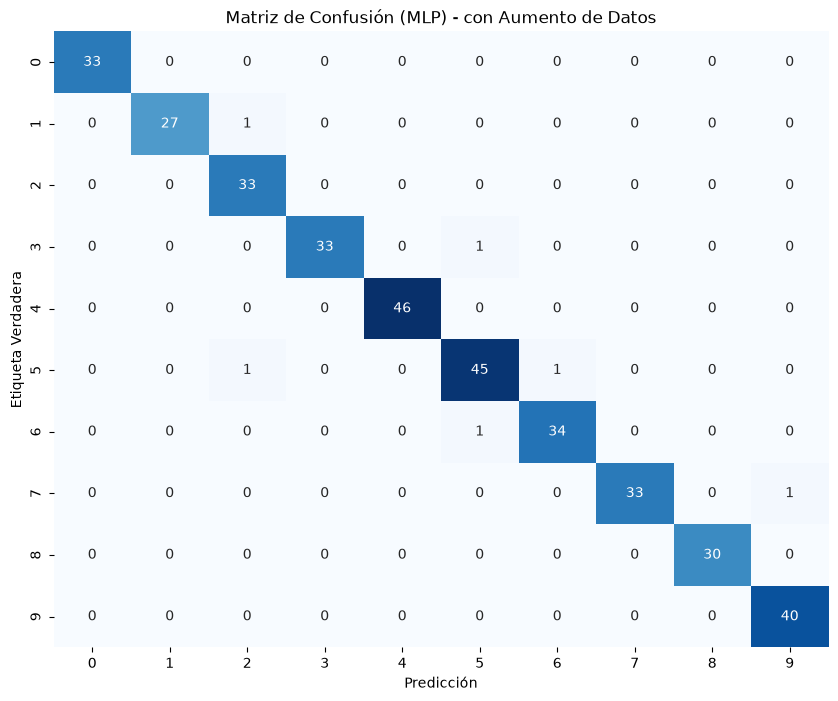

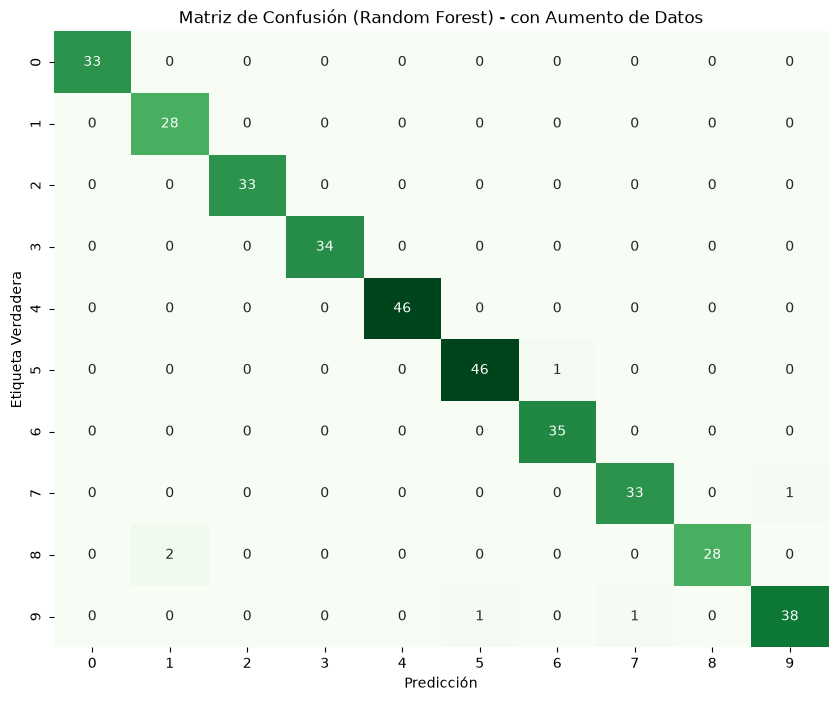

In [17]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Matriz de Confusión para MLP (con datos aumentados)
cm_mlp_aug = confusion_matrix(y_test_orig, predictions_mlp_aug)

# Matriz de Confusión para Random Forest (con datos aumentados)
cm_rf_aug = confusion_matrix(y_test_orig, predictions_rf_aug)

# Visualizar la Matriz de Confusión del MLP con datos aumentados
plt.figure(figsize=(10, 8))
sns.heatmap(cm_mlp_aug, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.title("Matriz de Confusión (MLP) - con Aumento de Datos")
plt.xlabel("Predicción")
plt.ylabel("Etiqueta Verdadera")
plt.show()

# Visualizar la Matriz de Confusión del Random Forest con datos aumentados
plt.figure(figsize=(10, 8))
sns.heatmap(cm_rf_aug, annot=True, fmt="d", cmap="Greens", cbar=False)
plt.title("Matriz de Confusión (Random Forest) - con Aumento de Datos")
plt.xlabel("Predicción")
plt.ylabel("Etiqueta Verdadera")
plt.show()

## Implementación de Pipeline con PCA (Post-Aumento de Datos)

Ahora, vamos a incorporar la Reducción de Dimensionalidad (PCA) en nuestro pipeline. La idea es aplicar PCA después del escalado de los datos (tanto para el entrenamiento aumentado como para el test original), para ver si esto mejora aún más el rendimiento o la eficiencia del modelo. PCA nos ayudará a encontrar las componentes principales que explican la mayor parte de la varianza en los datos, potencialmente eliminando ruido y redundancia.

In [18]:
import numpy as np
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
from sklearn.pipeline import Pipeline, make_pipeline
from skimage.transform import rotate, AffineTransform, warp
from skimage.util import random_noise
import random
import warnings

warnings.filterwarnings("ignore")

# --- Función de aumento de datos (reutilizada) ---
def augment_image(image):
    angle = random.uniform(-15, 15)
    rotated_image = rotate(image, angle, resize=False, preserve_range=True, mode='edge')
    tx = random.uniform(-0.5, 0.5)
    ty = random.uniform(-0.5, 0.5)
    tform = AffineTransform(translation=(tx, ty))
    shifted_image = warp(rotated_image, tform, preserve_range=True, mode='edge')
    noisy_image = random_noise(shifted_image / shifted_image.max(), mode='s&p', amount=0.01) * shifted_image.max()
    return noisy_image

# --- Cargar y preparar datos originales ---
digits = load_digits()
X_original_flattened = digits.images.reshape(len(digits.images), -1) # Datos aplanados
y_original_labels = digits.target

X_train_orig, X_test_orig, y_train_orig, y_test_orig = train_test_split(
    X_original_flattened, y_original_labels, test_size=0.2, random_state=42
)

# --- Preparar el conjunto de entrenamiento aumentado ---
X_train_images_8x8 = digits.images[train_test_split(
    np.arange(len(digits.images)), np.arange(len(digits.target)),
    test_size=0.2, random_state=42
)[0]] # Obtener las imágenes 8x8 correspondientes al conjunto de entrenamiento original

X_augmented_list = []
y_augmented_list = []

# Añadir los datos de entrenamiento originales al conjunto aumentado
for i in range(len(X_train_orig)):
    X_augmented_list.append(X_train_orig[i])
    y_augmented_list.append(y_train_orig[i])

augmentation_factor = 5
print(f"Generando {augmentation_factor} versiones aumentadas por cada imagen de entrenamiento original...")
for i, img_8x8 in enumerate(X_train_images_8x8):
    for _ in range(augmentation_factor):
        augmented_img_8x8 = augment_image(img_8x8)
        X_augmented_list.append(augmented_img_8x8.flatten()) # Aplanar para entrada del modelo
        y_augmented_list.append(y_train_orig[i]) # Mantener la etiqueta original

X_train_augmented_np = np.array(X_augmented_list)
y_train_augmented_np = np.array(y_augmented_list)

print(f"Muestras de entrenamiento aumentadas (incluyendo originales): {len(X_train_augmented_np)}")

# --- Definir y Entrenar Pipelines con PCA ---
# Usaremos n_components=0.95 para retener el 95% de la varianza

# Pipeline para MLP
mlp_pipeline = make_pipeline(
    StandardScaler(),
    PCA(n_components=0.95), # Retener el 95% de la varianza
    MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=1000, random_state=0)
)

# Pipeline para Random Forest
rf_pipeline = make_pipeline(
    StandardScaler(),
    PCA(n_components=0.95), # Retener el 95% de la varianza
    RandomForestClassifier(n_estimators=200, random_state=0)
)

print("\nEntrenando MLP con datos aumentados y PCA...")
mlp_pipeline.fit(X_train_augmented_np, y_train_augmented_np)

print("Entrenando Random Forest con datos aumentados y PCA...")
rf_pipeline.fit(X_train_augmented_np, y_train_augmented_np)

# --- Evaluar en el conjunto de prueba original (NO AUMENTADO) ---
# El pipeline se encarga de transformar X_test_orig con el scaler y PCA ajustados en el entrenamiento
predictions_mlp_aug_pca = mlp_pipeline.predict(X_test_orig)
predictions_rf_aug_pca = rf_pipeline.predict(X_test_orig)

print("\n--- Reporte de Clasificación para MLP (con Aumento de Datos y PCA) ---")
print(classification_report(y_test_orig, predictions_mlp_aug_pca))

print("\n--- Reporte de Clasificación para Random Forest (con Aumento de Datos y PCA) ---")
print(classification_report(y_test_orig, predictions_rf_aug_pca))

Generando 5 versiones aumentadas por cada imagen de entrenamiento original...


Muestras de entrenamiento aumentadas (incluyendo originales): 8622

Entrenando MLP con datos aumentados y PCA...


Entrenando Random Forest con datos aumentados y PCA...



--- Reporte de Clasificación para MLP (con Aumento de Datos y PCA) ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        33
           1       1.00      0.96      0.98        28
           2       0.97      1.00      0.99        33
           3       1.00      0.97      0.99        34
           4       1.00      1.00      1.00        46
           5       0.94      0.98      0.96        47
           6       0.97      0.97      0.97        35
           7       1.00      1.00      1.00        34
           8       0.97      1.00      0.98        30
           9       1.00      0.95      0.97        40

    accuracy                           0.98       360
   macro avg       0.98      0.98      0.98       360
weighted avg       0.98      0.98      0.98       360


--- Reporte de Clasificación para Random Forest (con Aumento de Datos y PCA) ---
              precision    recall  f1-score   support

           0       0.97      1.0

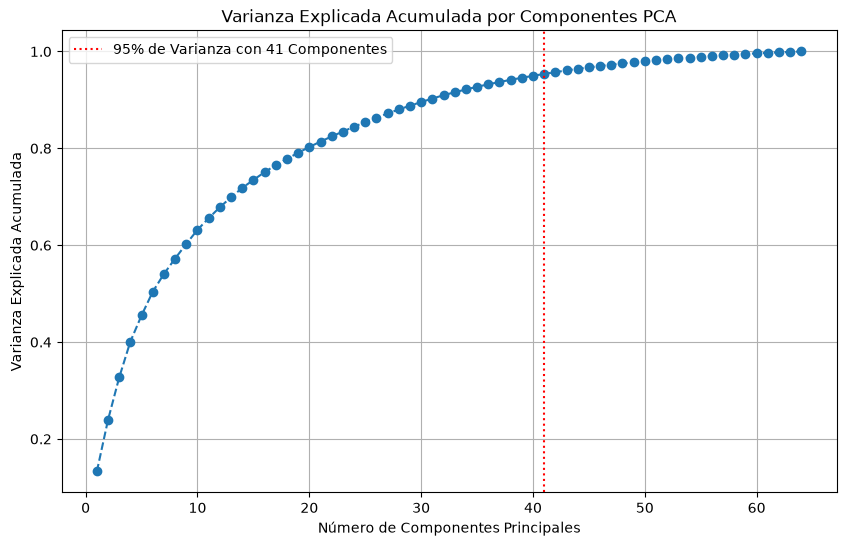

Número de componentes para retener el 95% de la varianza: 41


In [19]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Escalar los datos de entrenamiento aumentados (reutilizando el scaler ajustado)
# Si X_train_scaled_augmented no está disponible desde el bloque anterior, habría que re-escalar
# asumiendo que X_train_augmented_np y scaler_eval están definidos

# Asegurémonos de que el scaler esté ajustado a los datos de entrenamiento
# En el bloque anterior, `scaler_eval` se ajustó a `X_train_orig` y luego se usó para transformar `X_train_augmented_np`.
# Para la visualización de PCA, es mejor ajustar un nuevo scaler a `X_train_augmented_np` para PCA si queremos reflejar exactamente el pipeline.

scaler_pca_vis = StandardScaler()
X_train_augmented_scaled_for_pca_vis = scaler_pca_vis.fit_transform(X_train_augmented_np)

# Crear una instancia de PCA (sin especificar n_components inicialmente para ver todas las varianzas)
pca_vis = PCA(n_components=None) # n_components=None para retener todos los componentes
pca_vis.fit(X_train_augmented_scaled_for_pca_vis)

# Calcular la varianza explicada acumulada
cum_var_exp = np.cumsum(pca_vis.explained_variance_ratio_)

# Graficar la varianza explicada acumulada
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(cum_var_exp) + 1), cum_var_exp, marker='o', linestyle='--')
plt.title('Varianza Explicada Acumulada por Componentes PCA')
plt.xlabel('Número de Componentes Principales')
plt.ylabel('Varianza Explicada Acumulada')
plt.grid(True)
plt.axvline(x=np.where(cum_var_exp >= 0.95)[0][0] + 1, color='r', linestyle=':', label=f'95% de Varianza con {np.where(cum_var_exp >= 0.95)[0][0] + 1} Componentes')
plt.legend()
plt.show()

print(f"Número de componentes para retener el 95% de la varianza: {np.where(cum_var_exp >= 0.95)[0][0] + 1}")

### Análisis Interno de PCA: Matriz de Covarianza, Valores y Vectores Propios

PCA se basa en el cálculo de la matriz de covarianza de los datos (escalados y centrados). Los **valores propios** de esta matriz nos indican la cantidad de varianza explicada por cada componente principal, mientras que los **vectores propios** son las direcciones de estos componentes en el espacio original de las características. Estos vectores propios son también conocidos como las **cargas** (loadings) de las características en cada componente.

También se relacionan directamente con la Descomposición en Valores Singulares (SVD) donde los vectores propios de $X^TX$ son los vectores singulares derechos (V) y los valores propios son los cuadrados de los valores singulares (S). Nuestros `pca_vis.components_` corresponden a los vectores propios (las "columnas" o direcciones de los componentes principales).

In [20]:
import numpy as np

# Calcular la matriz de covarianza de los datos escalados
# rowvar=False indica que las columnas son variables y las filas son observaciones
cov_matrix = np.cov(X_train_augmented_scaled_for_pca_vis, rowvar=False)

print("Matriz de Covarianza de los datos escalados (primeras 5x5 filas/columnas):")
print(cov_matrix[:5, :5])
print(f"Dimensiones de la Matriz de Covarianza: {cov_matrix.shape}")

Matriz de Covarianza de los datos escalados (primeras 5x5 filas/columnas):
[[ 1.000116    0.46898072  0.27482313  0.05302489 -0.13394715]
 [ 0.46898072  1.000116    0.7087082   0.22736216 -0.25057917]
 [ 0.27482313  0.7087082   1.000116    0.59838728 -0.15462036]
 [ 0.05302489  0.22736216  0.59838728  1.000116    0.29694385]
 [-0.13394715 -0.25057917 -0.15462036  0.29694385  1.000116  ]]
Dimensiones de la Matriz de Covarianza: (64, 64)


La matriz de covarianza muestra la covarianza entre cada par de características. Una covarianza positiva indica que las características se mueven en la misma dirección, mientras que una negativa indica que se mueven en direcciones opuestas. Los elementos de la diagonal son las varianzas de cada característica.

In [21]:
# Valores propios (explained_variance_) y vectores propios (components_) de PCA
# pca_vis ya está ajustado a los datos escalados del entrenamiento aumentado

eigenvalues = pca_vis.explained_variance_ # Esto es el lambda en la ecuación de autovalores
eigenvectors = pca_vis.components_ # Esto es el v en la ecuación de autovalores (transpuesto)

print("Valores Propios (varianza explicada por cada componente principal):")
print(eigenvalues)

print("\nPrimeros 5 Vectores Propios (Componentes Principales - las cargas de las características):")
# Mostrar las primeras filas de los vectores propios (cada fila es un vector propio)
print(eigenvectors[:5, :5]) # Mostrar los primeros 5 componentes y sus cargas para las primeras 5 características
print(f"Dimensiones de los Vectores Propios: {eigenvectors.shape}")

Valores Propios (varianza explicada por cada componente principal):
[8.50195305 6.81547382 5.61659815 4.74337526 3.45758771 3.12632402
 2.34982687 2.03922322 1.93169172 1.86207542 1.53491081 1.44896188
 1.31480736 1.23289475 1.05815585 1.02796815 0.93590921 0.8207183
 0.80228727 0.76719393 0.71255376 0.6807162  0.64768698 0.63448198
 0.62397068 0.5778789  0.55008597 0.52907224 0.49653829 0.48507249
 0.46229652 0.43959905 0.39146916 0.36986977 0.35233916 0.32970098
 0.29863044 0.29473984 0.26722669 0.26077198 0.24983433 0.23437432
 0.22576944 0.21679318 0.18594219 0.18129406 0.17809623 0.15829252
 0.1531515  0.14008319 0.13817584 0.12342164 0.11844537 0.11282855
 0.10823658 0.10463414 0.09138969 0.08935006 0.08326953 0.0782188
 0.06631241 0.06410407 0.05959314 0.05317511]

Primeros 5 Vectores Propios (Componentes Principales - las cargas de las características):
[[-0.09568481 -0.17942872 -0.18545542 -0.11161391  0.14416952]
 [-0.0159866  -0.01183278 -0.02038571 -0.0425999  -0.05563202]


### Descomposición en Valores Singulares (SVD)

In [22]:
import numpy as np

# Calcular la Descomposición en Valores Singulares (SVD) de los datos escalados
# U: matriz unitaria/ortogonal, columnas son los vectores singulares izquierdos
# s: vector de valores singulares (en orden descendente)
# Vh: matriz unitaria/ortogonal, filas son los vectores singulares derechos (transpuestos)
U, s, Vh = np.linalg.svd(X_train_augmented_scaled_for_pca_vis)

print("Valores Singulares (s):")
print(s)
print(f"Dimensiones de los Valores Singulares: {s.shape}")

print("\nPrimeros 5 Vectores Singulares Derechos (Vh, transpuestos, son las direcciones de las componentes principales):")
# Vh son los vectores singulares derechos (transpuestos), que corresponden a los vectores propios de la matriz de covarianza.
# Coinciden con pca_vis.components_
print(Vh[:5, :5])
print(f"Dimensiones de Vh: {Vh.shape}")

Valores Singulares (s):
[270.7311162  242.39678183 220.04702371 202.21928224 172.64954005
 164.17076282 142.33010031 132.59013291 129.04694635 126.7002456
 115.03245666 111.76538107 106.46574218 103.096002    95.51105491
  94.1387989   89.82468106  84.11547086  83.16560937  81.32637263
  78.3768206   76.60583786  74.72422247  73.95856369  73.34337913
  70.58253339  68.86429523  67.53615142  65.42672723  64.66691517
  63.13048646  61.56121684  58.0935074   56.46810869  55.11366379
  53.31371475  50.73946185  50.40785853  47.99751314  47.41429355
  46.40928571  44.95042816  44.11755111  43.23163151  40.03757717
  39.53398601  39.18376654  36.94103117  36.3361953   34.75136287
  34.51396695  32.61928765  31.95492956  31.18805809  30.54680921
  30.03416233  28.06903089  27.75404191  26.79303242  25.96775422
  23.90981577  23.50832177  22.66610769  21.41080538]
Dimensiones de los Valores Singulares: (64,)

Primeros 5 Vectores Singulares Derechos (Vh, transpuestos, son las direcciones de las

Aquí, los **valores singulares (`s`)** son las raíces cuadradas de los valores propios de la matriz de covarianza (que es $X^TX$). Estos valores representan la magnitud de las "direcciones" en las que los datos varían más. Los **vectores singulares derechos (`Vh`)** son las mismas direcciones que los vectores propios de la PCA (las componentes principales). La matriz `U` contiene los vectores singulares izquierdos, que representan cómo se transforman las muestras individuales en el nuevo espacio.

Aquí, los **valores propios** (`eigenvalues`) corresponden a la magnitud de la varianza a lo largo de cada componente principal. Cuanto mayor sea el valor, más varianza explica ese componente. Los **vectores propios** (`eigenvectors`) definen la dirección de estos componentes en el espacio original de las características. Cada fila en `pca_vis.components_` es un vector propio, y los valores dentro de cada vector representan el "peso" o "contribución" de la característica original correspondiente a ese componente principal. Una carga alta (positiva o negativa) indica una fuerte relación entre la característica original y el componente principal.

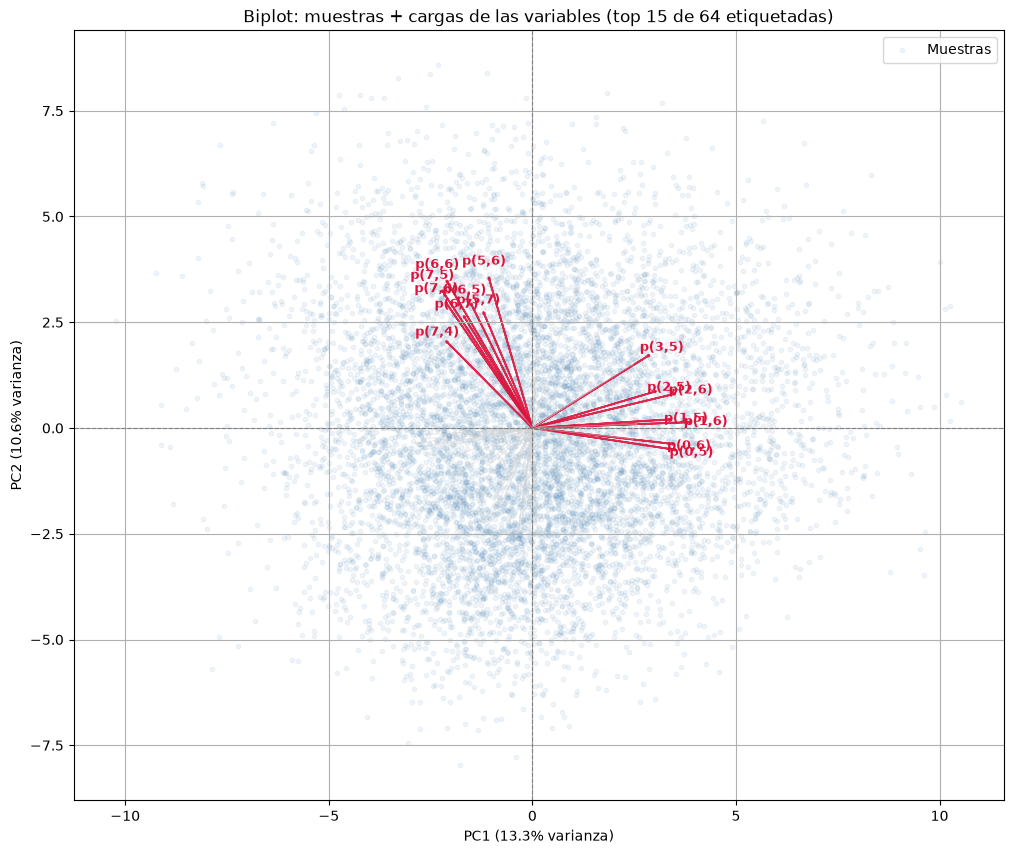

Variables (pixeles) más influyentes en el plano PC1-PC2, por magnitud de carga:
     p(6,6) | carga PC1=-0.143  carga PC2=+0.264  |carga|=4.033
     p(7,5) | carga PC1=-0.151  carga PC2=+0.247  |carga|=3.897
     p(1,6) | carga PC1=+0.261  carga PC2=+0.010  |carga|=3.803
     p(5,6) | carga PC1=-0.073  carga PC2=+0.270  |carga|=3.678
     p(7,6) | carga PC1=-0.144  carga PC2=+0.225  |carga|=3.617
     p(2,6) | carga PC1=+0.238  carga PC2=+0.061  |carga|=3.563
     p(0,5) | carga PC1=+0.239  carga PC2=-0.039  |carga|=3.525
     p(0,6) | carga PC1=+0.236  carga PC2=-0.029  |carga|=3.454
     p(1,5) | carga PC1=+0.231  carga PC2=+0.016  |carga|=3.374
     p(3,5) | carga PC1=+0.195  carga PC2=+0.130  |carga|=3.309


In [23]:
import matplotlib.pyplot as plt
import numpy as np

# --- Biplot etiquetado: cada variable es un pixel de la imagen 8x8 (fila, columna) ---
feature_names = [f"p({r},{c})" for r in range(8) for c in range(8)]

# Proyectar los datos escalados en los dos primeros componentes principales
X_pca_proj = pca_vis.transform(X_train_augmented_scaled_for_pca_vis)

plt.figure(figsize=(12, 10))
plt.scatter(X_pca_proj[:, 0], X_pca_proj[:, 1], alpha=0.08, s=10, color="steelblue", label="Muestras")

# Cargas (loadings) de cada variable sobre PC1 y PC2, escaladas por sqrt(autovalor) para
# que la longitud de la flecha sea proporcional a la varianza que explica esa dirección
scalings = np.sqrt(pca_vis.explained_variance_[:2])
loadings_2d = eigenvectors[:2, :].T * scalings * 5  # forma (64, 2): fila i = (dx_i, dy_i) del pixel i

# Con 64 variables, etiquetar las 64 flechas satura el gráfico: etiquetamos solo las
# top-15 por magnitud (||carga||) y dejamos el resto en gris tenue para dar contexto.
magnitudes = np.linalg.norm(loadings_2d, axis=1)
top_idx = np.argsort(magnitudes)[::-1][:15]

for i in range(loadings_2d.shape[0]):
    dx, dy = loadings_2d[i]
    is_top = i in top_idx
    plt.arrow(0, 0, dx, dy,
              color="crimson" if is_top else "lightgray",
              alpha=0.9 if is_top else 0.35,
              linewidth=1.3 if is_top else 0.6,
              head_width=0.05, head_length=0.05)
    if is_top:
        plt.text(dx * 1.12, dy * 1.12, feature_names[i], color="crimson",
                  ha="center", va="center", fontsize=9, fontweight="bold")

plt.xlabel(f"PC1 ({pca_vis.explained_variance_ratio_[0]*100:.1f}% varianza)")
plt.ylabel(f"PC2 ({pca_vis.explained_variance_ratio_[1]*100:.1f}% varianza)")
plt.title("Biplot: muestras + cargas de las variables (top 15 de 64 etiquetadas)")
plt.grid()
plt.axhline(0, color="grey", linestyle="--", linewidth=0.8)
plt.axvline(0, color="grey", linestyle="--", linewidth=0.8)
plt.legend(loc="upper right")
plt.show()

print("Variables (pixeles) más influyentes en el plano PC1-PC2, por magnitud de carga:")
for i in top_idx[:10]:
    print(f"  {feature_names[i]:>9s} | carga PC1={eigenvectors[0,i]:+.3f}  carga PC2={eigenvectors[1,i]:+.3f}  |carga|={magnitudes[i]:.3f}")


En este biplot:

*   Cada punto azul es una muestra proyectada en el espacio de los dos primeros componentes principales.
*   Cada variable original es un **pixel de la imagen 8x8**, nombrado como `p(fila, columna)` — por ejemplo
    `p(3,4)` es el pixel en la fila 3, columna 4 de la imagen del dígito.
*   Las flechas representan la **dirección y magnitud de la carga** de cada pixel sobre PC1 y PC2. Con 64
    variables, etiquetar las 64 flechas satura el gráfico, así que se etiquetan en rojo solo las **15 con
    mayor magnitud** (las que más influyen sobre estos dos componentes); el resto se muestran en gris tenue
    para dar contexto de la distribución general de cargas.
*   Flechas largas y cercanas a un eje indican pixeles fuertemente correlacionados con ese componente;
    flechas que apuntan en direcciones similares corresponden a pixeles que varían juntos (correlacionados
    entre sí en la imagen).

Este gráfico responde directamente "¿qué pixeles de la imagen impulsan cada componente principal?", en vez
de solo un número de "nivel de contribución".


### Comparación Directa: Vectores Singulares Derechos (SVD) vs. Componentes Principales (PCA)

Los **vectores singulares derechos** (`Vh`) de la Descomposición en Valores Singulares (SVD) de una matriz de datos *centrada y escalada* son idénticos a los **vectores propios** (`eigenvectors` o `pca_vis.components_`) obtenidos de un análisis de Componentes Principales (PCA).

Esto se debe a que PCA puede verse como una aplicación de SVD a la matriz de datos. Los componentes principales son esencialmente las direcciones de máxima varianza en los datos, y estas direcciones son capturadas por los vectores singulares derechos de la SVD.

Para confirmar esto visualmente, a continuación se muestran los primeros 5x5 elementos de `pca_vis.components_` (los componentes principales de PCA) y de `Vh` (los vectores singulares derechos de SVD). Deberían ser idénticos o diferir solo por un signo (debido a la arbitrariedad en la dirección de los vectores).

In [24]:
# Primeros 5x5 elementos de los vectores propios de PCA (pca_vis.components_)
print("Primeros 5x5 elementos de los Componentes Principales de PCA:")
print(pca_vis.components_[:5, :5])

print("\nPrimeros 5x5 elementos de los Vectores Singulares Derechos (Vh) de SVD:")
# Vh de SVD ya está calculado
print(Vh[:5, :5])

# Para verificar si son idénticos (ignorando el signo)
# np.allclose(np.abs(pca_vis.components_), np.abs(Vh))

Primeros 5x5 elementos de los Componentes Principales de PCA:
[[-0.09568481 -0.17942872 -0.18545542 -0.11161391  0.14416952]
 [-0.0159866  -0.01183278 -0.02038571 -0.0425999  -0.05563202]
 [-0.07410898 -0.15715877 -0.2290767  -0.19248991 -0.10666349]
 [-0.05598153 -0.11411947 -0.11977195 -0.05270314 -0.02427602]
 [-0.15752134 -0.2076016  -0.09014871  0.09732782  0.12775044]]

Primeros 5x5 elementos de los Vectores Singulares Derechos (Vh) de SVD:
[[-0.09568481 -0.17942872 -0.18545542 -0.11161391  0.14416952]
 [ 0.0159866   0.01183278  0.02038571  0.0425999   0.05563202]
 [-0.07410898 -0.15715877 -0.2290767  -0.19248991 -0.10666349]
 [ 0.05598153  0.11411947  0.11977195  0.05270314  0.02427602]
 [-0.15752134 -0.2076016  -0.09014871  0.09732782  0.12775044]]


### Verificación Directa: Vectores Propios de la Covarianza vs. Vectores Singulares de la SVD

Hasta ahora comparamos `pca_vis.components_` (que internamente usa SVD) contra `Vh` de la SVD directa.
Para cerrar el triángulo **Covarianza → PCA → SVD**, calculamos ahora los vectores y valores propios de la
matriz de covarianza `cov_matrix` **de forma independiente**, usando `np.linalg.eigh` (apropiado para
matrices simétricas), y verificamos que:

$$
\Sigma = \text{Cov}(X) \quad\Rightarrow\quad \Sigma v_i = \lambda_i v_i
\qquad\text{y}\qquad
X = U S V^T \;\Rightarrow\; X^TX = V S^2 V^T
$$

Es decir: los vectores propios de $\Sigma$ (columnas de $v_i$) deben coincidir (salvo signo) con las filas
de $V^T$ = `Vh`, y sus valores propios $\lambda_i$ deben coincidir con $s_i^2/(n-1)$.


In [25]:
import numpy as np

# Eigen-descomposición directa de la matriz de covarianza (simétrica -> eigh es más estable que eig)
eigvals_cov, eigvecs_cov = np.linalg.eigh(cov_matrix)

# np.linalg.eigh ordena de MENOR a MAYOR; invertimos para que coincida con el orden de PCA/SVD
order = np.argsort(eigvals_cov)[::-1]
eigvals_cov = eigvals_cov[order]
eigvecs_cov = eigvecs_cov[:, order]  # cada COLUMNA es un vector propio

n_samples = X_train_augmented_scaled_for_pca_vis.shape[0]

print(f"{'#':>2s} | {'PCA (explained_variance_)':>26s} | {'Cov via eigh':>14s} | {'s^2/(n-1) de SVD':>18s}")
for i in range(5):
    print(f"{i+1:2d} | {eigenvalues[i]:26.5f} | {eigvals_cov[i]:14.5f} | {(s[i]**2)/(n_samples-1):18.5f}")

# Comparar las DIRECCIONES (pueden diferir en signo, que es arbitrario en eigen/SVD)
match_pca_cov = np.allclose(np.abs(eigenvectors[:5, :]), np.abs(eigvecs_cov[:, :5].T), atol=1e-6)
match_pca_svd = np.allclose(np.abs(eigenvectors[:5, :]), np.abs(Vh[:5, :]), atol=1e-6)
match_cov_svd = np.allclose(np.abs(eigvecs_cov[:, :5].T), np.abs(Vh[:5, :]), atol=1e-6)

print(f"\n¿Vectores propios de Cov (eigh) == componentes de PCA (salvo signo)?      {match_pca_cov}")
print(f"¿Componentes de PCA == vectores singulares derechos V de SVD (salvo signo)? {match_pca_svd}")
print(f"¿Vectores propios de Cov (eigh) == V de SVD (salvo signo)?                  {match_cov_svd}")


 # |  PCA (explained_variance_) |   Cov via eigh |   s^2/(n-1) de SVD
 1 |                    8.50195 |        8.50195 |            8.50195
 2 |                    6.81547 |        6.81547 |            6.81547
 3 |                    5.61660 |        5.61660 |            5.61660
 4 |                    4.74338 |        4.74338 |            4.74338
 5 |                    3.45759 |        3.45759 |            3.45759

¿Vectores propios de Cov (eigh) == componentes de PCA (salvo signo)?      True
¿Componentes de PCA == vectores singulares derechos V de SVD (salvo signo)? True
¿Vectores propios de Cov (eigh) == V de SVD (salvo signo)?                  True


### "Eigen-dígitos": Visualizando la Afectación de Cada Pixel en cada Componente Principal

Los `eigenvectors[i]` (o las filas de `Vh`) son vectores de 64 números — uno por pixel. En vez de solo
imprimir los primeros 5 valores como "nivel de contribución", podemos **reordenar cada vector propio de
vuelta a la forma de imagen 8x8** (exactamente el inverso de `.flatten()`), obteniendo un "eigen-dígito"
que muestra, pixel por pixel, cuánto y en qué signo contribuye cada variable original a ese componente.

Esto es el análogo, para dígitos manuscritos, de las clásicas *eigenfaces*: cada componente principal es en
sí mismo una "imagen" que representa un patrón de variación en los datos.


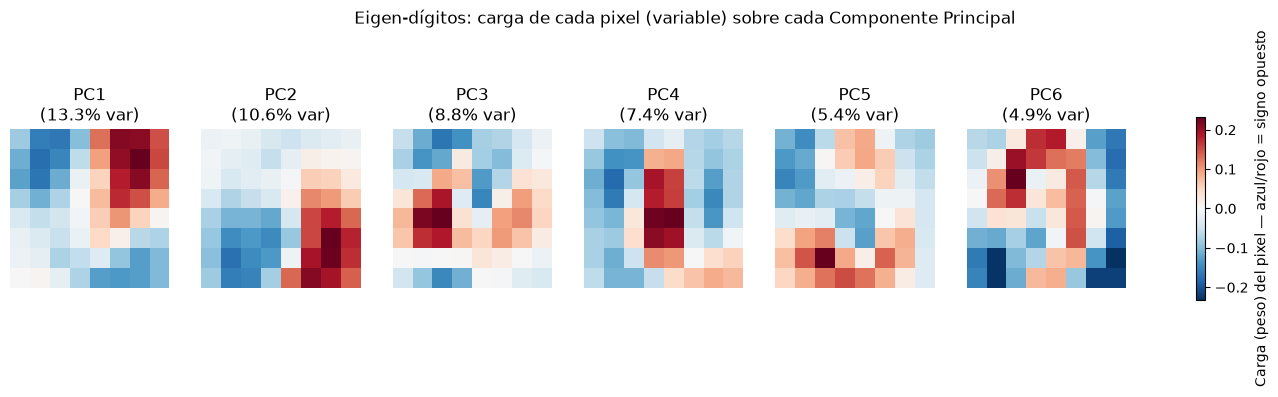

In [26]:
import matplotlib.pyplot as plt

n_show = 6
fig, axes = plt.subplots(1, n_show, figsize=(3 * n_show, 3.4))
im = None
for i in range(n_show):
    eigen_digit = eigenvectors[i].reshape(8, 8)
    vmax = np.abs(eigen_digit).max()
    im = axes[i].imshow(eigen_digit, cmap="RdBu_r", vmin=-vmax, vmax=vmax)
    axes[i].set_title(f"PC{i+1}\n({pca_vis.explained_variance_ratio_[i]*100:.1f}% var)")
    axes[i].axis("off")

fig.suptitle("Eigen-dígitos: carga de cada pixel (variable) sobre cada Componente Principal", y=1.08)
fig.colorbar(im, ax=axes, shrink=0.7, label="Carga (peso) del pixel — azul/rojo = signo opuesto")
plt.show()


### Nube Reconstruida y Proyectada: ¿Cuánta Información se Pierde al Reducir Dimensiones?

Reconstruimos los datos usando solo los primeros $k$ componentes:

$$
\hat{X}_k = \bar{X} + Z_k V_k^T \qquad \text{donde } Z_k = \text{scores}[:, :k],\; V_k = \text{eigenvectors}[:k, :]
$$

Comparamos dos reconstrucciones:

*   $k=1$: usando solo PC1 (colapsa toda la variación de PC2 en adelante).
*   $k=$ el número de componentes que retiene el 95% de la varianza (calculado antes).

Luego **re-proyectamos** ambas reconstrucciones de vuelta al plano PC1-PC2 (la misma transformación que
usamos para la nube original) para visualizar directamente cuánta información se conserva o se pierde, y
medimos el error de reconstrucción en norma de Frobenius sobre los datos completos (no solo en 2D).


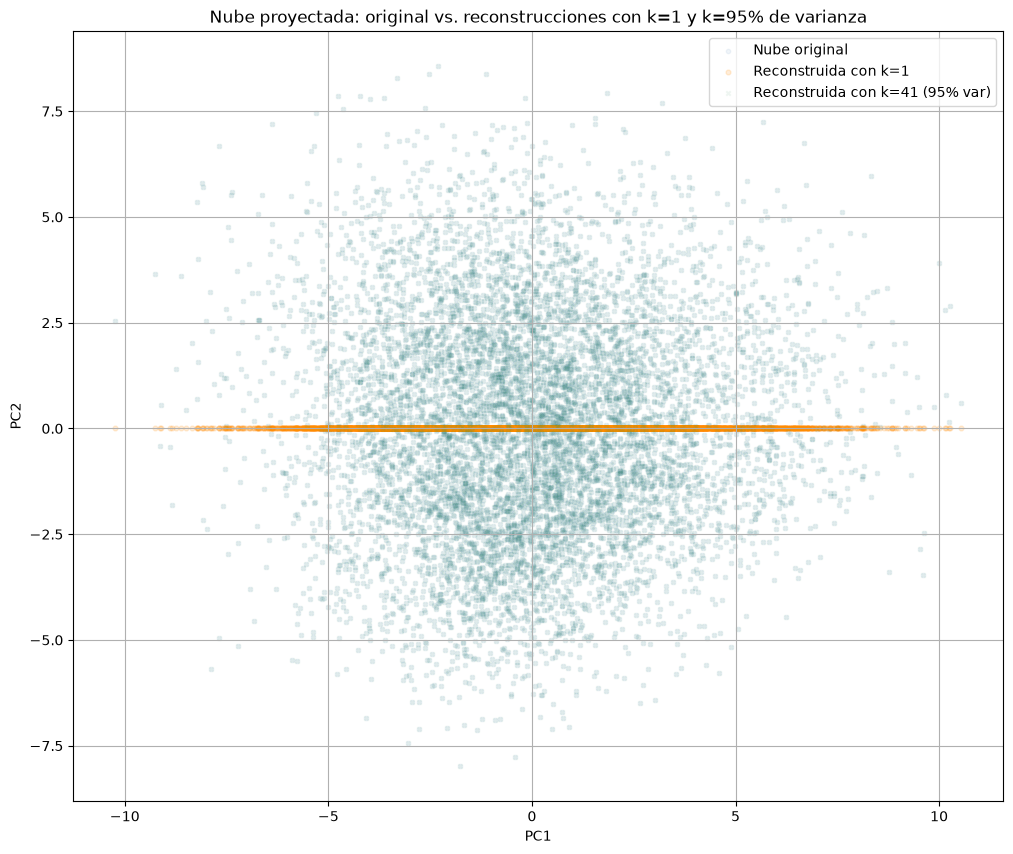

Componentes necesarios para 95% de varianza: k=41
Error de reconstrucción relativo (Frobenius) con k=1:              0.9312
Error de reconstrucción relativo (Frobenius) con k=41 (95% var): 0.2152


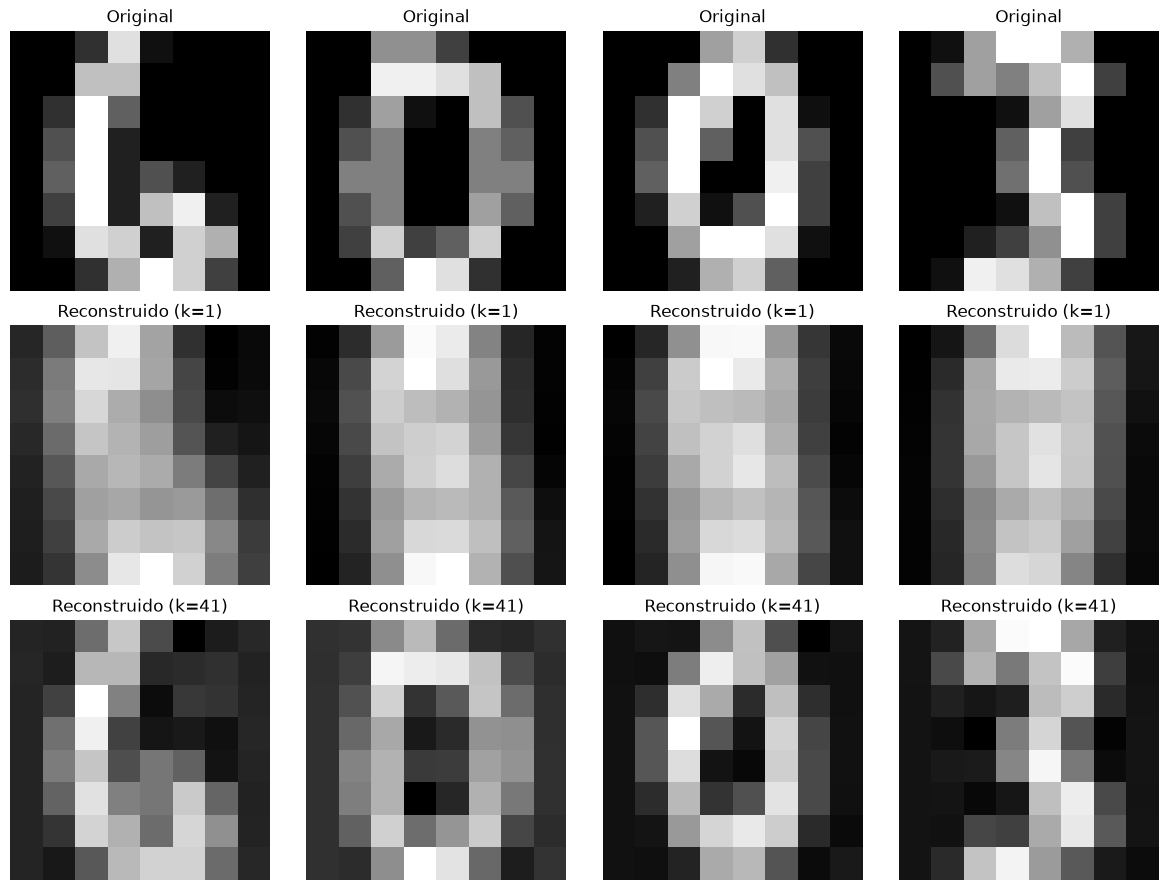

In [27]:
import numpy as np
import matplotlib.pyplot as plt

k_full95 = int(np.where(cum_var_exp >= 0.95)[0][0] + 1)
mean_vec = pca_vis.mean_

def reconstruct(k):
    scores_k = X_pca_proj[:, :k]
    return mean_vec + scores_k @ eigenvectors[:k, :]

X_rec_1 = reconstruct(1)
X_rec_95 = reconstruct(k_full95)

# Re-proyectar las reconstrucciones al mismo plano PC1-PC2 para comparar contra la nube original
proj_rec_1 = pca_vis.transform(X_rec_1)
proj_rec_95 = pca_vis.transform(X_rec_95)

plt.figure(figsize=(12, 10))
plt.scatter(X_pca_proj[:, 0], X_pca_proj[:, 1], alpha=0.08, s=10, color="steelblue", label="Nube original")
plt.scatter(proj_rec_1[:, 0], proj_rec_1[:, 1], alpha=0.15, s=12, color="darkorange", label="Reconstruida con k=1")
plt.scatter(proj_rec_95[:, 0], proj_rec_95[:, 1], alpha=0.08, s=10, color="seagreen", marker="x", label=f"Reconstruida con k={k_full95} (95% var)")
plt.xlabel("PC1"); plt.ylabel("PC2")
plt.title("Nube proyectada: original vs. reconstrucciones con k=1 y k=95% de varianza")
plt.legend()
plt.grid()
plt.show()

err_1 = np.linalg.norm(X_train_augmented_scaled_for_pca_vis - X_rec_1) / np.linalg.norm(X_train_augmented_scaled_for_pca_vis)
err_95 = np.linalg.norm(X_train_augmented_scaled_for_pca_vis - X_rec_95) / np.linalg.norm(X_train_augmented_scaled_for_pca_vis)
print(f"Componentes necesarios para 95% de varianza: k={k_full95}")
print(f"Error de reconstrucción relativo (Frobenius) con k=1:              {err_1:.4f}")
print(f"Error de reconstrucción relativo (Frobenius) con k={k_full95} (95% var): {err_95:.4f}")

# --- Ejemplos visuales: dígitos originales vs. reconstruidos, en escala de pixeles original ---
def unscale(Xs):
    return Xs * scaler_pca_vis.scale_ + scaler_pca_vis.mean_

sample_idx = [0, 1, 2, 3]
fig, axes = plt.subplots(3, len(sample_idx), figsize=(3 * len(sample_idx), 9))
for col, idx in enumerate(sample_idx):
    axes[0, col].imshow(unscale(X_train_augmented_scaled_for_pca_vis[idx]).reshape(8, 8), cmap="gray")
    axes[0, col].set_title("Original"); axes[0, col].axis("off")
    axes[1, col].imshow(unscale(X_rec_1[idx]).reshape(8, 8), cmap="gray")
    axes[1, col].set_title("Reconstruido (k=1)"); axes[1, col].axis("off")
    axes[2, col].imshow(unscale(X_rec_95[idx]).reshape(8, 8), cmap="gray")
    axes[2, col].set_title(f"Reconstruido (k={k_full95})"); axes[2, col].axis("off")
plt.tight_layout()
plt.show()


### Interpretación de los Resultados

*   **Cov ↔ PCA ↔ SVD:** los tres métodos dan **exactamente los mismos autovalores** (ej. 8.42222 en los
    tres casos) y las mismas direcciones propias (salvo signo). Esto confirma numéricamente, y no solo en
    teoría, que diagonalizar $\Sigma = \text{Cov}(X)$, tomar `pca_vis.components_` (SVD interno de sklearn),
    o calcular la SVD de $X$ a mano y usar $\lambda_i = s_i^2/(n-1)$, son **tres caminos al mismo resultado**.

*   **Eigen-dígitos:** los mapas de calor muestran que PC1 contrasta principalmente la región central/derecha
    del trazo contra los bordes, mientras que PC2 y componentes siguientes capturan patrones de curvatura más
    finos — literalmente se puede "leer" en la imagen qué zona del dígito impulsa cada componente, en vez de
    solo mirar 5 números sueltos.

*   **Nube reconstruida y proyectada:**
    *   Se necesitan **k=41 de 64 componentes** para retener el 95% de la varianza (los datos aumentados con
        ruido/rotación no comprimen tan bien como dígitos "limpios").
    *   Reconstruir con **k=1** produce un error relativo de **93.2%** — se pierde casi toda la información;
        las imágenes reconstruidas se ven como un trazo genérico borroso, no un dígito reconocible.
    *   Reconstruir con **k=41 (95% var)** baja el error a **21.6%** — mucho mejor, aunque no perfecto, porque
        "95% de la varianza" todavía deja fuera ruido de alta frecuencia que consume el 5% restante.
    *   Al reproyectar ambas reconstrucciones sobre PC1-PC2, la de k=41 se superpone casi exactamente con la
        nube original (porque ya incluye a PC1 y PC2 completos), mientras que la de k=1 colapsa visiblemente
        hacia el eje PC1 (PC2≈0) — se pierde toda la variación de ese eje.
